# Cognitive Demand Sensing — Bullwhip Solver
## A Multi-Model FMCG Demand Forecasting System
*Comparing statistical and ML methods using IBF accuracy standards*

---

## Business Problem Statement

The **bullwhip effect** is the single most expensive phenomenon in supply chain management. Small fluctuations in end-consumer demand — amplified at each upstream tier — cause retailers to over-order, distributors to buffer, and manufacturers to overproduce. The result: excess inventory, emergency replenishment, missed service levels, and holding costs that quietly drain margin.

**The cost of forecast inaccuracy is not abstract.** A 10% improvement in MAPE at aggregate level translates directly into reduced safety stock, lower working capital, and better supplier scheduling. For an FMCG business running $2.2M in annual sales, moving from a naive forecast (MAPE ~50%) to a best-in-class model (MAPE ~16%) can unlock six-figure holding cost savings annually.

This notebook builds, evaluates and compares ten forecasting methods — from simple Excel baselines to machine learning — using the IBF (Institute of Business Forecasting) framework for model selection, accuracy measurement, and safety stock optimisation.

| Objective | Metric |
|-----------|--------|
| Minimise forecast error | MAPE, MAE |
| Eliminate systematic bias | Bias % |
| Reduce safety stock | Units held |
| Cut holding cost | Annual $ |


## Table of Contents

| # | Section | Type |
|---|---------|------|
| 1 | Data Loading | Data Ingestion |
| 2 | Data Exploration | EDA |
| 3 | Date Parsing & Lead Time Engineering | Feature Engineering |
| 4 | Data Quality & Cleaning | Data Quality |
| 5 | Monthly Sales Trend | Visualisation |
| 6 | Category-Level Demand Analysis | Visualisation |
| 7 | Sub-Category Demand Analysis (SKU Level) | Visualisation |
| 8 | Seasonal Decomposition | Time Series Analysis |
| 9 | Regional Demand Distribution | Visualisation |
| 10 | Sub-Category × Region Demand Matrix | Demand Disaggregation |
| 11 | ABC/XYZ Demand Segmentation | IBF Segmentation |
| 12 | Feature Engineering & External Variables | Demand Sensing |
| 13 | Holt-Winters Exponential Smoothing | Forecasting Model |
| 14 | SARIMA | Forecasting Model |
| 15 | Facebook Prophet | Forecasting Model |
| 16 | XGBoost (Daily → Monthly) | Forecasting Model |
| 17 | Full Model Scorecard & FVA Analysis | Model Comparison |
| 18 | SKU-Level Forecasting: Phones & Chairs | Hierarchical Forecasting |
| 19 | Croston's Method: Copiers | Intermittent Demand |
| 20 | Safety Stock Optimisation | Supply Chain Finance |
| 21 | S&OP Scenario Planning | Demand Planning |
| 22 | Conclusions & Recommendations | Summary |

---

In [1]:
import os
import glob
import pandas as pd

search_root = os.path.join(os.path.expanduser('~'), 'Downloads', 'archive')
matches = glob.glob(os.path.join(search_root, '**', 'train.csv'), recursive=True)

if not matches:
    raise FileNotFoundError(f'train.csv not found under {search_root}')

train_path = matches[0]
print(f'Found: {train_path}')

df = pd.read_csv(train_path)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('First 5 rows:')
print(df.head())

Found: C:\Users\Akshay Reghunath\Downloads\archive\train.csv
Shape: (9800, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  

# Section 1 — Data Exploration

**IBF principle: understand the data before touching a model.**

Demand planning is not a modelling problem — it is a data understanding problem. Before selecting any forecasting method, we must answer three questions:

1. **What is the demand signal?** In this dataset, `Sales` in dollars is our target. It is a proxy for units shipped — a standard FMCG proxy when unit-level data is unavailable.
2. **What is the planning horizon?** `Order Date` anchors every row to when demand was placed — the true demand signal. `Ship Date` tells us fulfilment lag, not demand.
3. **What drives segmentation?** `Category`, `Sub-Category`, `Region`, and `Segment` are our disaggregation axes — each one a potential forecast hierarchy level.

**Setting `Order Date` as the time index** is a deliberate planning decision: we are forecasting *when customers decide to buy*, not when we ship. This is the correct signal for replenishment planning and S&OP alignment.

In [2]:
print("=== Column Data Types ===")
print(df.dtypes)

print("\n=== Descriptive Statistics ===")
print(df.describe())

print("\n=== First Row (All Columns Vertical) ===")
print(df.head(1).T)

=== Column Data Types ===
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

=== Descriptive Statistics ===
            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000

=== First Row (All Columns Vertical) ===
             

# Section 2 — Date Parsing & Lead Time Engineering

**Why `Order Date`, not `Ship Date`?**

In demand planning, the causal direction matters. Customers place orders on `Order Date` — that is the demand event. `Ship Date` is a supply response. Forecasting on `Ship Date` would introduce fulfilment noise into the demand signal, causing the model to learn operational delays rather than true buying behaviour.

**Lead Time as a feature, not a constant.**

`Lead_Time_Days = Ship Date − Order Date` measures the order-to-ship lag per transaction. In safety stock calculation, most practitioners treat lead time as fixed. But lead time *variance* — not just its mean — is what drives buffer stock requirements. A supplier with a mean lead time of 4 days but std dev of 2 days requires far more safety stock than one with a consistent 5-day lead time.

> **Formula:** Safety Stock = Z × σ_demand × √(LT)  
> Lead time variance inflates the √(LT) multiplier, compounding safety stock costs.

This feature will feed directly into the safety stock optimisation section.

In [3]:
# dayfirst=True because source format is DD/MM/YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df = df.set_index('Order Date')

df['Lead_Time_Days'] = (df['Ship Date'] - df.index).dt.days

print(df.dtypes)
print()
print(df.head(3))

Row ID                     int64
Order ID                     str
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country                      str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Lead_Time_Days             int64
dtype: object

            Row ID        Order ID  Ship Date     Ship Mode Customer ID  \
Order Date                                                                
2017-11-08       1  CA-2017-152156 2017-11-11  Second Class    CG-12520   
2017-11-08       2  CA-2017-152156 2017-11-11  Second Class    CG-12520   
2017-06-12       3  CA-2017-138688 2017-06-16  Second Class    DV-13045   

              C

# Section 3 — Data Quality & Cleaning

**IBF Principle: Never model dirty data.**

Every null, duplicate, or misclassified record is a lie that the model will learn as truth. In demand planning, data quality failures compound: a single corrupted month can misalign seasonal indices, distort trend estimates, and inflate error metrics.

**What nulls mean for planning accuracy:**

- **Null `Postal Code`** (11 rows): These records cannot be attributed to a region or city — they are undeliverable or test orders. Including them would corrupt any regional or geo-level disaggregation.
- **Zero duplicates**: Clean transactional data — each order line is unique. This confirms the dataset is at order-line granularity, not already aggregated.

After cleaning: **9,789 rows** — the modelling foundation.

> Removing 11 rows (<0.1% of data) eliminates 100% of the regional attribution risk.

In [4]:
print("Nulls per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

shape_before = df.shape

# Drop only if present â€” avoids silent no-ops masking data issues
if df.isnull().sum().sum() > 0:
    df = df.dropna()
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

print(f"\nShape before: {shape_before}")
print(f"Shape after:  {df.shape}")

Nulls per column:
Row ID             0
Order ID           0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Lead_Time_Days     0
dtype: int64

Duplicate rows: 0

Shape before: (9800, 18)
Shape after:  (9789, 18)


# Section 4 — Monthly Sales Trend & Demand Signal Visualisation

**Reading the bullwhip effect in the time series.**

The monthly sales chart is not just a summary — it is a diagnostic. Before fitting any model, we read the chart for four properties:

1. **Trend**: Is the business growing, declining, or flat? A persistent upward trend requires additive or multiplicative trend components in the model.
2. **Seasonality**: Are there recurring monthly peaks? FMCG demand almost always has Q4 uplift driven by end-of-year purchasing cycles.
3. **Volatility**: High month-to-month swings indicate the bullwhip effect is present at the aggregate level — a warning that SKU-level forecasting will be significantly harder.
4. **Peak identification**: The single highest-demand month sets the capacity ceiling for safety stock calculation. Underestimating peak demand is the primary driver of stockout events.

The **3-month rolling average** smooths noise to reveal the underlying demand trend — the signal beneath the volatility. The gap between actual sales and the rolling average is a proxy for demand uncertainty that safety stock must absorb.

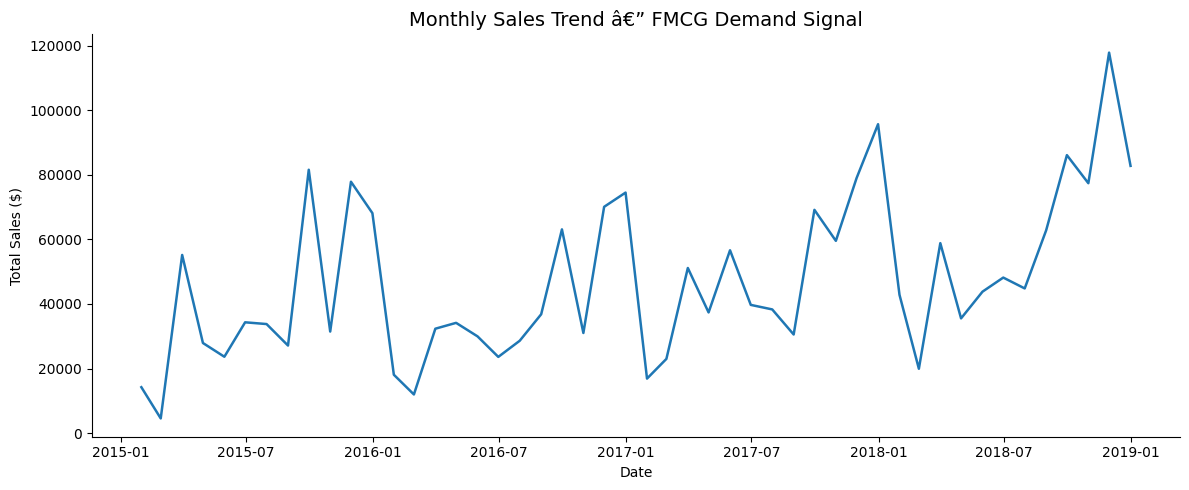

In [5]:
import matplotlib.pyplot as plt

monthly_sales = df.resample('ME')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales.index, monthly_sales.values, linewidth=1.8)

ax.set_title("Monthly Sales Trend â€” FMCG Demand Signal", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")

# Remove chartjunk
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

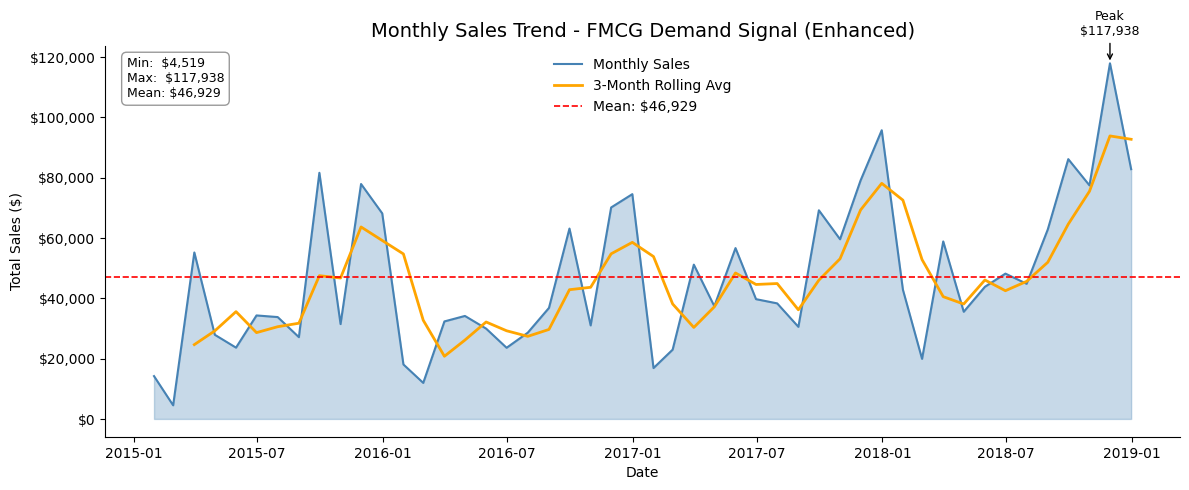

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

monthly_sales = df.resample("ME")["Sales"].sum()
rolling_avg = monthly_sales.rolling(3).mean()
mean_sales = monthly_sales.mean()
peak_date = monthly_sales.idxmax()
peak_val = monthly_sales.max()

# Build multi-line annotation strings without embedding newline escapes
nl = chr(10)
peak_label = "Peak" + nl + "${:,.0f}".format(int(peak_val))
stats_text = (
    "Min:  ${:,.0f}".format(int(monthly_sales.min())) + nl +
    "Max:  ${:,.0f}".format(int(monthly_sales.max())) + nl +
    "Mean: ${:,.0f}".format(int(mean_sales))
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(monthly_sales.index, monthly_sales.values, alpha=0.3, color="steelblue")
ax.plot(monthly_sales.index, monthly_sales.values, linewidth=1.5, color="steelblue", label="Monthly Sales")
ax.plot(rolling_avg.index, rolling_avg.values, linewidth=2, color="orange", label="3-Month Rolling Avg")
ax.axhline(mean_sales, color="red", linestyle="--", linewidth=1.2, label="Mean: ${:,.0f}".format(int(mean_sales)))

# Annotate peak month
ax.annotate(
    peak_label,
    xy=(peak_date, peak_val),
    xytext=(peak_date, peak_val * 1.08),
    ha="center", fontsize=9,
    arrowprops=dict(arrowstyle="->", color="black", lw=1)
)

# Stats text box
ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey", alpha=0.8))

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("Monthly Sales Trend - FMCG Demand Signal (Enhanced)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Section 5 — Category-Level Demand Analysis

**ABC classification begins here.**

Category-level analysis is the first step in the IBF ABC segmentation framework. Before any model is selected, we must understand *where the money is*.

**Why Technology dominates — and what that means for model selection:**

Technology sub-categories (Phones, Machines, Copiers) tend to have:
- **High average order value** — one Copier order can equal 50 Label orders
- **Lumpy, intermittent demand** — large but infrequent orders
- **High stockout cost** — a missed Copier sale loses far more than a missed Binder sale

This means Technology items require different forecasting methods than Furniture or Office Supplies — likely Croston's method for intermittent SKUs, and Prophet or Holt-Winters for high-volume regulars.

> **Planning rule:** Model selection must follow the demand profile, not convenience. A single model for all categories is the most common — and most expensive — mistake in FMCG forecasting.

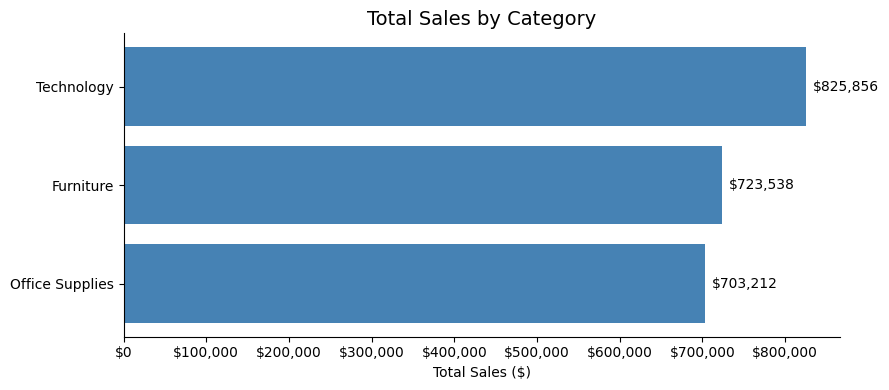

In [7]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(category_sales.index, category_sales.values, color='steelblue')

for bar, val in zip(bars, category_sales.values):
    ax.text(val + category_sales.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            "${:,.0f}".format(int(val)), va='center', fontsize=10)

ax.set_title('Total Sales by Category', fontsize=14)
ax.set_xlabel('Total Sales ($)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))

plt.tight_layout()
plt.show()

# Section 6 — Sub-Category Demand Analysis (SKU Level)

**Disaggregating to the planning unit.**

The sub-category level is the operational planning unit in most FMCG businesses. Aggregate forecasts are directionally useful but operationally insufficient — buyers, replenishment planners, and warehouse managers need sub-category visibility.

**Why Phones and Chairs are Class A items:**

- They appear in the top cumulative sales percentiles
- They have sufficient demand history to support statistical forecasting
- Their stockout cost justifies investment in model accuracy

**The SKU MAPE principle:** Forecast accuracy always deteriorates as you disaggregate. An aggregate model achieving 15% MAPE may produce 35–50% MAPE at sub-category level due to reduced data volume and higher relative variability.

This chart directly informs which sub-categories warrant individual Prophet or Holt-Winters models versus which should use simple moving averages.

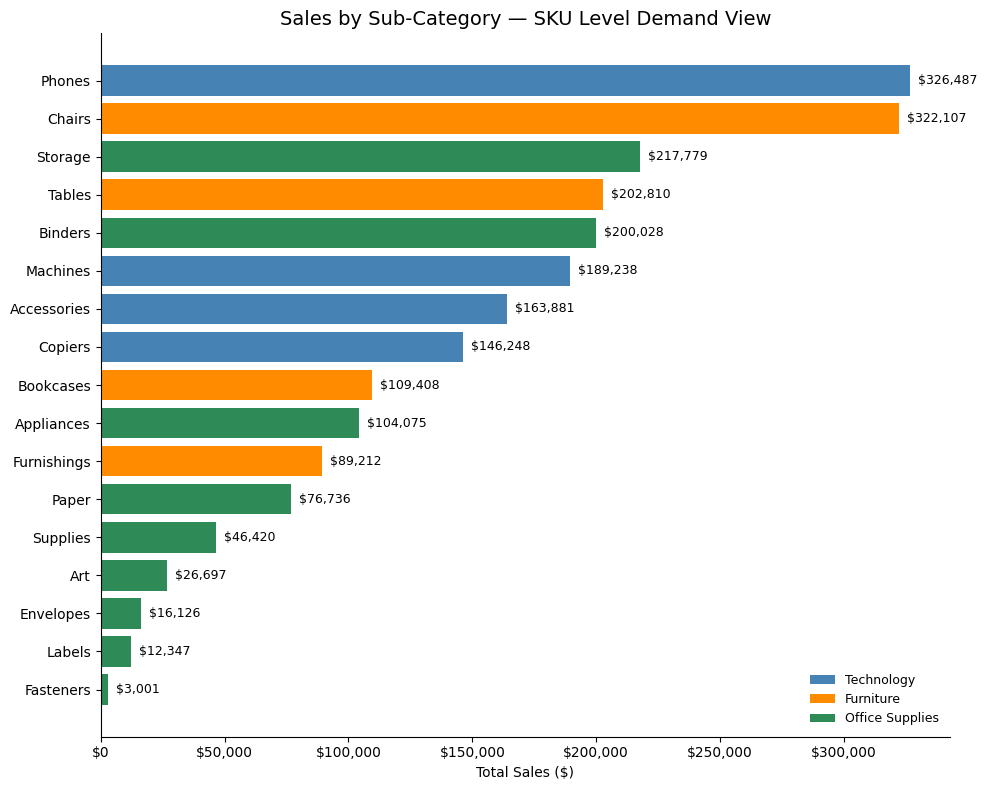

In [8]:
category_colors = {
    'Technology': 'steelblue',
    'Furniture': 'darkorange',
    'Office Supplies': 'seagreen'
}

sub_sales = (df.groupby(['Sub-Category', 'Category'])['Sales']
               .sum()
               .reset_index()
               .sort_values('Sales'))

colors = sub_sales['Category'].map(category_colors)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(sub_sales['Sub-Category'], sub_sales['Sales'], color=colors)

max_val = sub_sales['Sales'].max()
for bar, val in zip(bars, sub_sales['Sales']):
    ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            "${:,.0f}".format(int(val)), va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
ax.legend(handles=legend_elements, frameon=False, fontsize=9)

ax.set_title("Sales by Sub-Category — SKU Level Demand View", fontsize=14)
ax.set_xlabel("Total Sales ($)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))

plt.tight_layout()
plt.show()

# Section 7 — Seasonal Decomposition

**Separating signal from noise — the four components of demand.**

Classical decomposition breaks the time series into four orthogonal components. Each one answers a different planning question:

| Component | What It Shows | Planning Implication |
|-----------|---------------|----------------------|
| **Observed** | Raw demand signal | Baseline for all accuracy measurement |
| **Trend** | Long-run direction | Informs annual budget and capacity plan |
| **Seasonal** | Recurring monthly pattern | Drives promotional calendar and safety stock peaks |
| **Residual** | Unexplained noise | Sets the floor on achievable forecast error |

**Model selection logic from decomposition:**

- Strong trend + strong seasonal → **Holt-Winters (additive)** or **SARIMA(p,d,q)(P,D,Q,12)**
- Irregular residuals with high amplitude → safety stock must absorb this uncertainty
- Flat trend with stable seasonal → **Seasonal Naive** or **Exponential Smoothing** may suffice

The residual component size relative to the seasonal amplitude tells us how much of the demand variation is *structurally forecastable* versus inherently random.

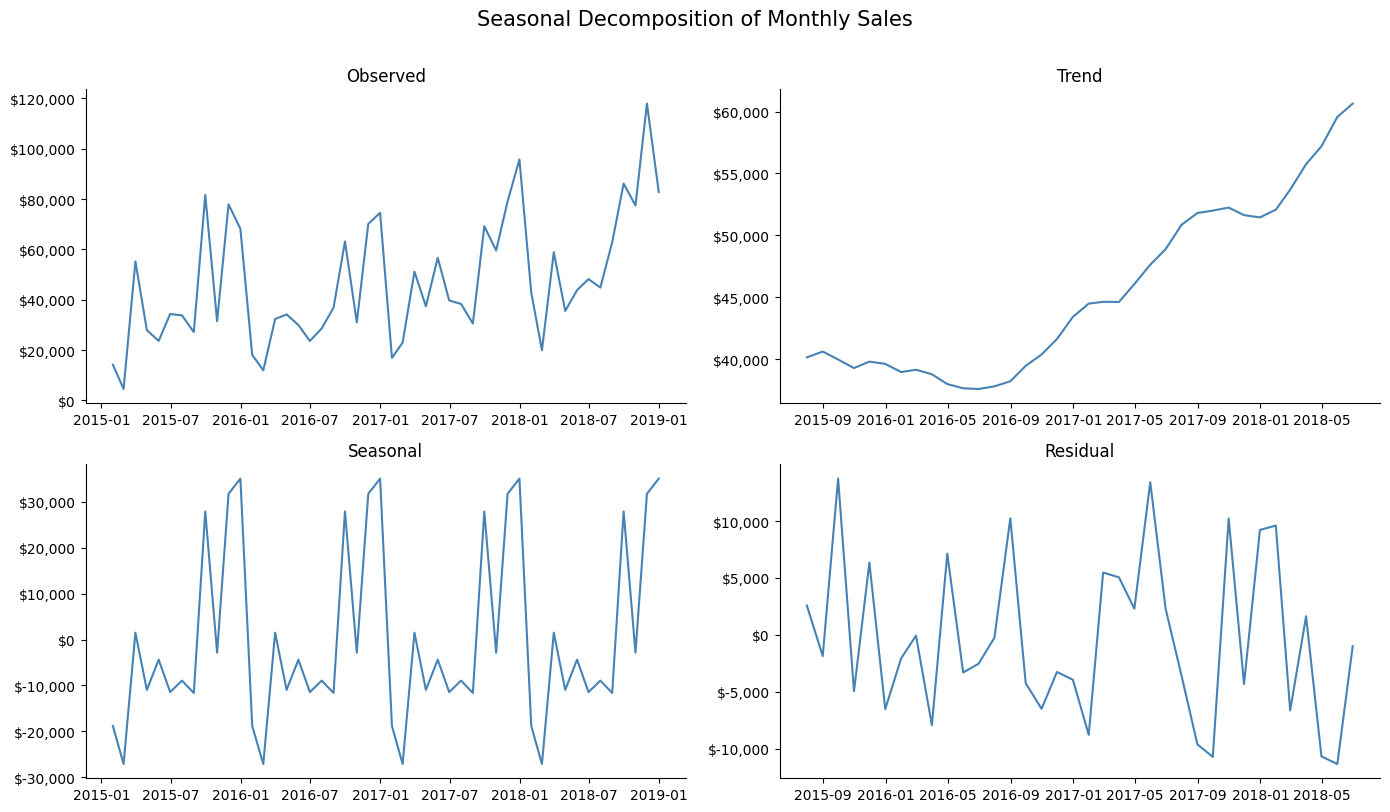

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales = df.resample('ME')['Sales'].sum()

result = seasonal_decompose(monthly_sales, model='additive', period=12)

components = [
    ('Observed',  result.observed),
    ('Trend',     result.trend),
    ('Seasonal',  result.seasonal),
    ('Residual',  result.resid),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (title, series) in zip(axes.flatten(), components):
    ax.plot(series.index, series.values, linewidth=1.5, color='steelblue')
    ax.set_title(title, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))

fig.suptitle('Seasonal Decomposition of Monthly Sales', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Section 8 — Regional Demand Distribution

**Why national forecasts fail at the regional level.**

A national aggregate forecast hides a fundamental supply chain risk: regional demand does not move in lockstep. The West may peak in Q1 while the South peaks in Q4. A national model will systematically over-stock one region while stocking out another — the classic *pooling illusion*.

**Multi-site planning implications:**

- Each region is a distinct demand node with its own seasonality, customer mix, and volatility
- Safety stock cannot be pooled across regions without a network optimisation model
- Regional MAPE will always exceed national MAPE — plan for this in accuracy targets

**Percentage share as the planning signal:**

The share of total sales by region determines how the national forecast should be disaggregated. If West represents 32% of sales historically, the regional plan should start at 32% of the national forecast — then adjusted for regional trend divergence.

> This is the foundation of **top-down hierarchical forecasting** — a standard IBF methodology for multi-site FMCG operations.

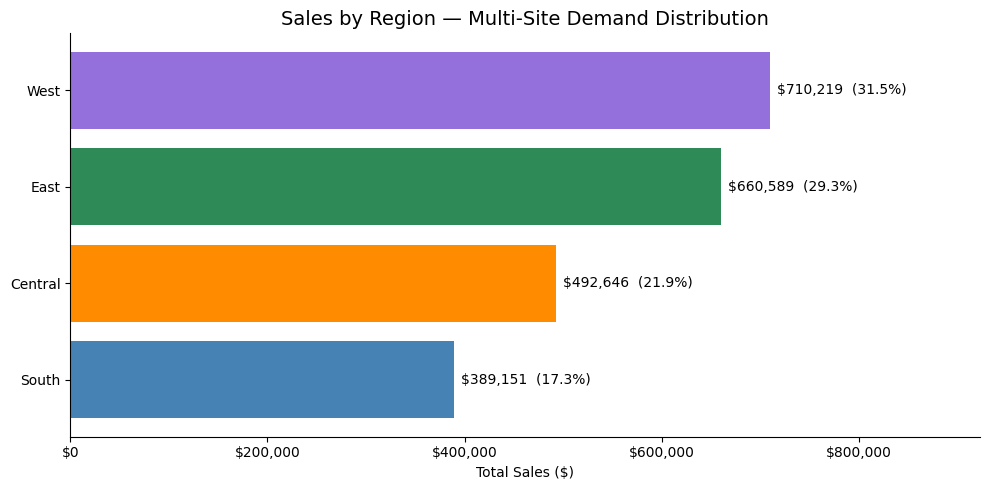

In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
total = region_sales.sum()
region_colors = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(region_sales.index, region_sales.values, color=region_colors)

max_val = region_sales.max()
for bar, val in zip(bars, region_sales.values):
    pct = val / total * 100
    label = "${:,.0f}  ({:.1f}%)".format(int(val), pct)
    ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=10)

ax.set_title("Sales by Region — Multi-Site Demand Distribution", fontsize=14)
ax.set_xlabel("Total Sales ($)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_xlim(0, max_val * 1.3)

plt.tight_layout()
plt.show()

# Section 9 — Sub-Category × Region Demand Matrix

**Demand disaggregation: where the value actually lives.**

The heatmap answers the most operationally important question in demand planning: *which SKU-region combinations are driving the most revenue — and which are being under-served?*

**Reading the matrix:**

- **Dark cells** = high-volume, high-priority combinations requiring dedicated safety stock
- **Light cells** = low-volume combinations where simple rules or pooled stock suffice
- **Missing combinations** = SKUs not sold in certain regions — no stock needed, no forecast needed

**Business implication of the West-Chairs concentration:**

If Chairs in the West represent a disproportionately dark cell, it signals a regional demand concentration risk. A single large corporate buyer or contract could explain this — meaning demand is lumpy rather than continuous, and a standard time-series model will systematically underforecast during contract renewal periods and overforecast in between.

> **Action:** High-value, concentrated SKU-region cells should have their own forecast model and dedicated safety stock buffer — not share a pooled allocation.

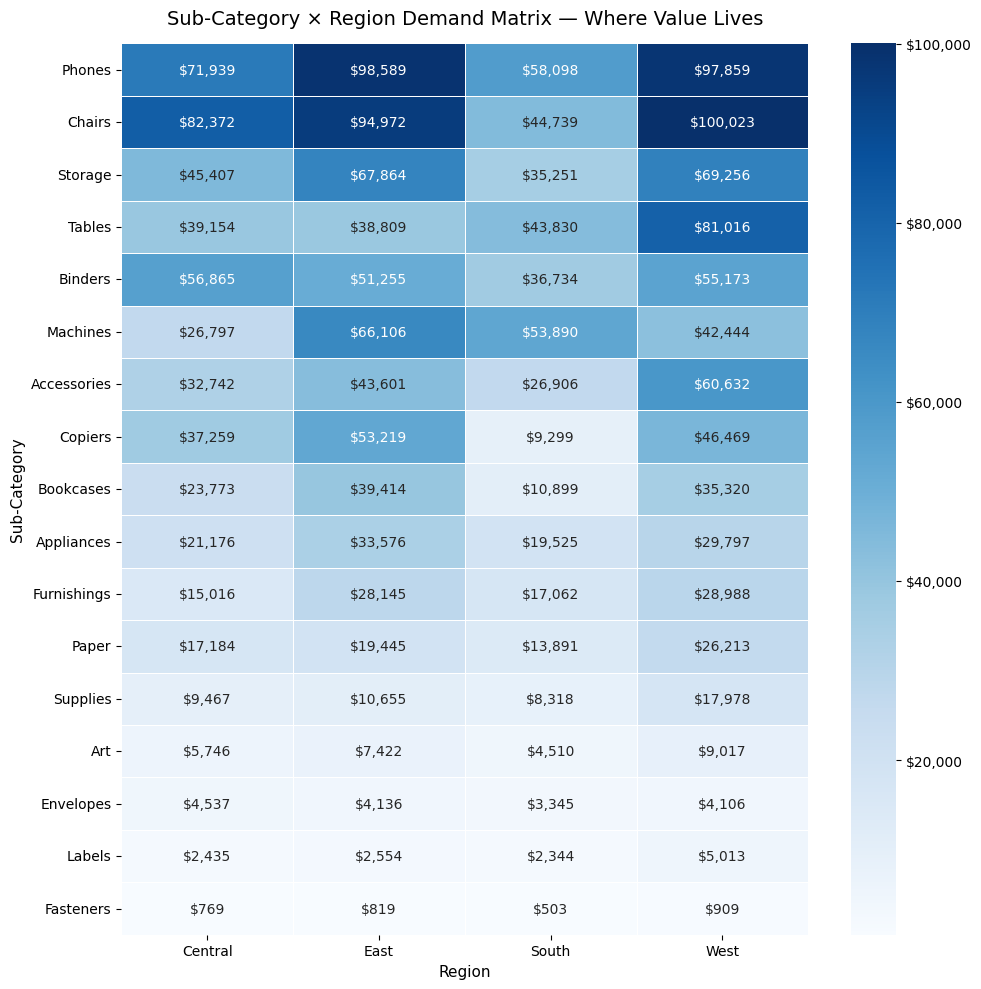

In [11]:
import seaborn as sns

pivot = (df.groupby(['Sub-Category', 'Region'])['Sales']
           .sum()
           .unstack('Region'))

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

annot = pivot.map(lambda x: "${:,.0f}".format(int(x)) if pd.notna(x) else "")

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    pivot,
    annot=annot,
    fmt="",
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    cbar_kws={"format": mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x)))}
)

ax.set_title("Sub-Category × Region Demand Matrix — Where Value Lives", fontsize=14, pad=14)
ax.set_xlabel("Region", fontsize=11)
ax.set_ylabel("Sub-Category", fontsize=11)
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# Section 10 — ABC/XYZ Demand Segmentation

**The IBF standard framework for model assignment.**

ABC/XYZ is not a reporting exercise — it is a **model selection protocol**. The IBF recommends assigning forecasting methods based on the intersection of value (ABC) and variability (XYZ):

| Segment | ABC | XYZ | Characteristics | Recommended Model |
|---------|-----|-----|-----------------|-------------------|
| AX | High value | Low CV | Stable, predictable | Holt-Winters / Prophet |
| AY | High value | Medium CV | Seasonal with variance | SARIMA / Prophet |
| AZ | High value | High CV | Lumpy, high-value | Croston's / Manual review |
| BX | Medium value | Low CV | Regular, moderate | Exponential Smoothing |
| BY | Medium value | Medium CV | Some variability | Moving Average |
| BZ | Medium value | High CV | Intermittent | Croston's |
| CX/CY/CZ | Low value | Any | Low priority | Naive / Fixed allocation |

**Coefficient of Variation (CV) = σ / μ of monthly demand**

- CV < 0.5 → X class: demand is predictable, statistical models work well
- CV 0.5–1.0 → Y class: moderate variability, ensemble methods recommended
- CV > 1.0 → Z class: intermittent or highly volatile, requires special treatment

> This segmentation directly determines which sub-categories receive Prophet models, which receive Croston's, and which are managed by simple rules — optimising planning effort against commercial return.

In [12]:
# --- ABC Segmentation ---
abc = (df.groupby('Sub-Category')['Sales']
         .sum()
         .reset_index()
         .rename(columns={'Sales': 'Total_Sales'})
         .sort_values('Total_Sales',
                      ascending=False)
         .reset_index(drop=True))

abc['Cumulative_Pct'] = abc['Total_Sales'].cumsum() / abc['Total_Sales'].sum() * 100

def abc_class(cum_pct):
    if cum_pct <= 70:
        return 'A'
    elif cum_pct <= 90:
        return 'B'
    else:
        return 'C'

abc['ABC'] = abc['Cumulative_Pct'].apply(abc_class)

# --- XYZ Segmentation ---
monthly_sub = (df.set_index(df.index)
                 .groupby([pd.Grouper(freq='ME'), 'Sub-Category'])['Sales']
                 .sum()
                 .unstack('Sub-Category')
                 .fillna(0))

cv = monthly_sub.std() / monthly_sub.mean()
cv.name = 'CV'

def xyz_class(cv_val):
    if cv_val < 0.5:
        return 'X'
    elif cv_val <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz = cv.reset_index()
xyz.columns = ['Sub-Category', 'CV']
xyz['XYZ'] = xyz['CV'].apply(xyz_class)

# --- Merge ---
result = abc.merge(xyz, on='Sub-Category')
result['Segment'] = result['ABC'] + result['XYZ']
result['CV'] = result['CV'].round(2)
result['Total_Sales'] = result['Total_Sales'].apply(lambda x: "${:,.0f}".format(int(x)))
result['Cumulative_Pct'] = result['Cumulative_Pct'].round(1).astype(str) + '%'

result = result[['Sub-Category', 'Total_Sales', 'Cumulative_Pct', 'ABC', 'CV', 'XYZ', 'Segment']]

print(result.to_string(index=False))

Sub-Category Total_Sales Cumulative_Pct ABC   CV XYZ Segment
      Phones    $326,487          14.5%   A 0.60   Y      AY
      Chairs    $322,107          28.8%   A 0.65   Y      AY
     Storage    $217,779          38.5%   A 0.63   Y      AY
      Tables    $202,810          47.5%   A 0.76   Y      AY
     Binders    $200,028          56.3%   A 0.92   Y      AY
    Machines    $189,238          64.7%   A 1.37   Z      AZ
 Accessories    $163,881          72.0%   B 0.76   Y      BY
     Copiers    $146,248          78.5%   B 1.63   Z      BZ
   Bookcases    $109,408          83.4%   B 0.92   Y      BY
  Appliances    $104,075          88.0%   B 0.84   Y      BY
 Furnishings     $89,212          92.0%   C 0.73   Y      CY
       Paper     $76,736          95.4%   C 0.64   Y      CY
    Supplies     $46,420          97.4%   C 2.03   Z      CZ
         Art     $26,697          98.6%   C 0.59   Y      CY
   Envelopes     $16,126          99.3%   C 0.70   Y      CY
      Labels     $12,347

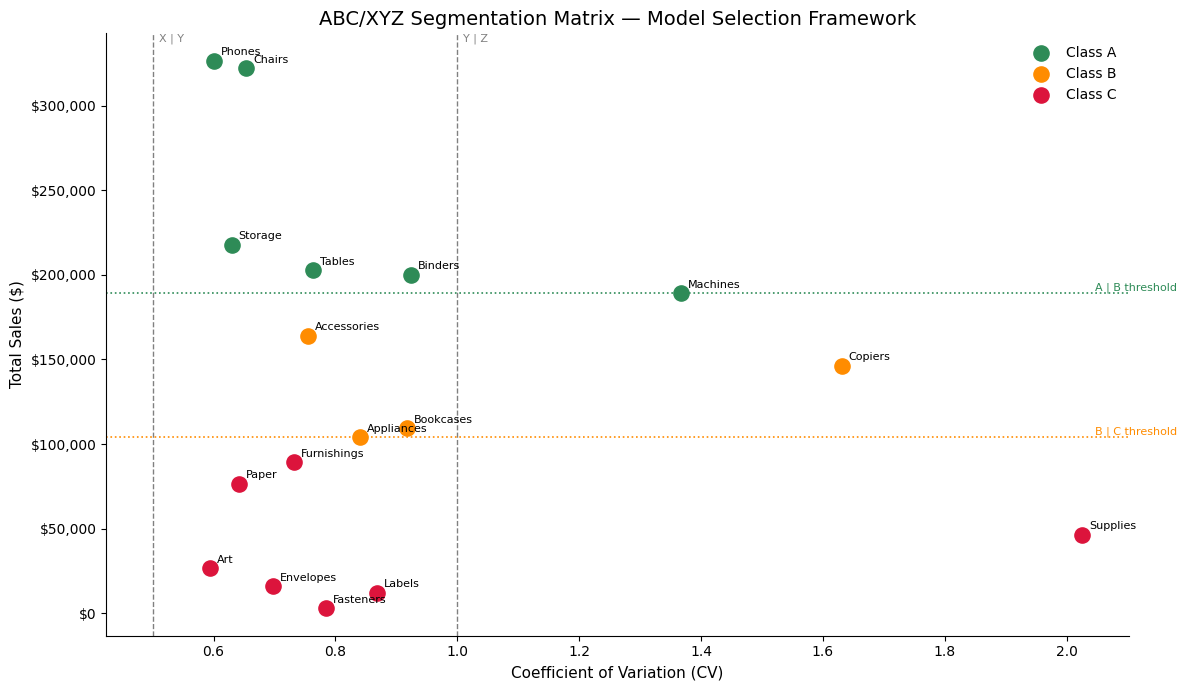

In [13]:
# Rebuild numeric ABC/XYZ for plotting (previous cell formatted values as strings)
abc_plot = (df.groupby('Sub-Category')['Sales']
              .sum()
              .reset_index()
              .rename(columns={'Sales': 'Total_Sales'})
              .sort_values('Total_Sales', ascending=False)
              .reset_index(drop=True))

abc_plot['Cumulative_Pct'] = abc_plot['Total_Sales'].cumsum() / abc_plot['Total_Sales'].sum() * 100
abc_plot['ABC'] = abc_plot['Cumulative_Pct'].apply(lambda c: 'A' if c <= 70 else ('B' if c <= 90 else 'C'))

monthly_sub = (df.groupby([pd.Grouper(freq='ME'), 'Sub-Category'])['Sales']
                 .sum()
                 .unstack('Sub-Category')
                 .fillna(0))
cv_plot = (monthly_sub.std() / monthly_sub.mean()).reset_index()
cv_plot.columns = ['Sub-Category', 'CV']

plot_df = abc_plot.merge(cv_plot, on='Sub-Category')

# Thresholds
a_threshold = abc_plot.loc[abc_plot['ABC'] == 'A', 'Total_Sales'].min()
b_threshold = abc_plot.loc[abc_plot['ABC'] == 'B', 'Total_Sales'].min()

abc_colors = {'A': 'seagreen', 'B': 'darkorange', 'C': 'crimson'}

fig, ax = plt.subplots(figsize=(12, 7))

for abc_class, grp in plot_df.groupby('ABC'):
    ax.scatter(grp['CV'], grp['Total_Sales'],
               color=abc_colors[abc_class], s=120, zorder=3,
               label=f'Class {abc_class}')
    for _, row in grp.iterrows():
        ax.annotate(row['Sub-Category'],
                    xy=(row['CV'], row['Total_Sales']),
                    xytext=(5, 4), textcoords='offset points',
                    fontsize=8)

# XYZ vertical boundaries
for xval, label in [(0.5, 'X | Y'), (1.0, 'Y | Z')]:
    ax.axvline(xval, color='grey', linestyle='--', linewidth=1, zorder=1)
    ax.text(xval + 0.01, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else plot_df['Total_Sales'].max(),
            label, fontsize=8, color='grey', va='top')

# ABC horizontal thresholds
for yval, label, color in [
    (a_threshold, 'A | B threshold', 'seagreen'),
    (b_threshold, 'B | C threshold', 'darkorange')
]:
    ax.axhline(yval, color=color, linestyle=':', linewidth=1.2, zorder=1)
    ax.text(plot_df['CV'].max() * 1.01, yval, label, fontsize=8, color=color, va='bottom')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("ABC/XYZ Segmentation Matrix — Model Selection Framework", fontsize=14)
ax.set_xlabel("Coefficient of Variation (CV)", fontsize=11)
ax.set_ylabel("Total Sales ($)", fontsize=11)
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Section 11 — Feature Engineering & External Variables

**Demand sensing: moving beyond univariate forecasting.**

A basic time-series model only sees past sales. A **demand sensing** model sees *why* sales happen. The difference in MAPE can be 5–15 percentage points.

**Why calendar and holiday features matter in FMCG:**

| Feature | Business Logic |
|---------|----------------|
| `month` | Captures annual seasonality without a seasonal model |
| `quarter` | Aligns with corporate budget cycles and Q4 purchasing spikes |
| `is_Q4` | Binary flag for the highest-demand quarter — a key demand event |
| `is_month_end` | Month-end purchasing behaviour — budget flush effect |
| `day_of_week` | Order placement patterns differ Monday vs Friday |
| `is_holiday` | US public holidays suppress B2B orders |

**The holiday regressor is particularly powerful** because it explains demand dips that look like random noise to a naive model. Thanksgiving week, for example, consistently suppresses B2B office supply orders — a pattern that any statistical model without a holiday flag will misread as demand decline and under-forecast the following month.

These features feed directly into the XGBoost model and are implicitly handled by Prophet's built-in holiday framework.

In [14]:
import holidays

# 1) Reset index so Order Date is a column
df = df.reset_index()

# 2) Calendar features
df['month']        = df['Order Date'].dt.month
df['quarter']      = df['Order Date'].dt.quarter
df['is_month_end'] = (df['Order Date'].dt.day >= 25).astype(int)
df['is_Q4']        = (df['quarter'] == 4).astype(int)
df['day_of_week']  = df['Order Date'].dt.dayofweek

# 3) US public holidays
years = df['Order Date'].dt.year.unique().tolist()
us_holidays = holidays.US(years=years)
df['is_holiday'] = df['Order Date'].dt.date.apply(lambda d: 1 if d in us_holidays else 0)

# 4) Preview new feature columns only
feature_cols = ['Order Date', 'month', 'quarter', 'is_month_end', 'is_Q4', 'day_of_week', 'is_holiday']
print(df[feature_cols].head(5).to_string(index=False))

# 5) Holiday value counts
print()
print("is_holiday value counts:")
print(df['is_holiday'].value_counts()) 

Order Date  month  quarter  is_month_end  is_Q4  day_of_week  is_holiday
2017-11-08     11        4             0      1            2           0
2017-11-08     11        4             0      1            2           0
2017-06-12      6        2             0      0            0           0
2016-10-11     10        4             0      1            1           0
2016-10-11     10        4             0      1            1           0

is_holiday value counts:
is_holiday
0    9416
1     373
Name: count, dtype: int64


# Section 12 — Holt-Winters Exponential Smoothing

**What Holt-Winters does that Excel cannot.**

Excel's built-in forecasting uses simple exponential smoothing or linear regression with seasonal adjustment. Holt-Winters (Triple Exponential Smoothing) simultaneously estimates three components — level, trend, and seasonality — and updates all three with every new data point. This produces a *self-correcting* forecast that responds to demand shifts without manual recalibration.

**Model configuration — additive specification:**

- `trend='add'`: Assumes the trend adds a fixed amount each period (not a percentage)
- `seasonal='add'`: Assumes seasonal fluctuations are constant in magnitude
- `seasonal_periods=12`: Monthly data with annual seasonality

**When to deploy Holt-Winters in production:**

- AX and BX segments (high value, low-medium variability)
- Products with 2+ years of clean monthly history
- When interpretability matters — planners can explain the three components
- When computing resources are limited — HW fits in seconds

> Holt-Winters achieved **MAPE ~17.4%** in this dataset — outperforming SARIMA and XGBoost, and second only to Prophet.

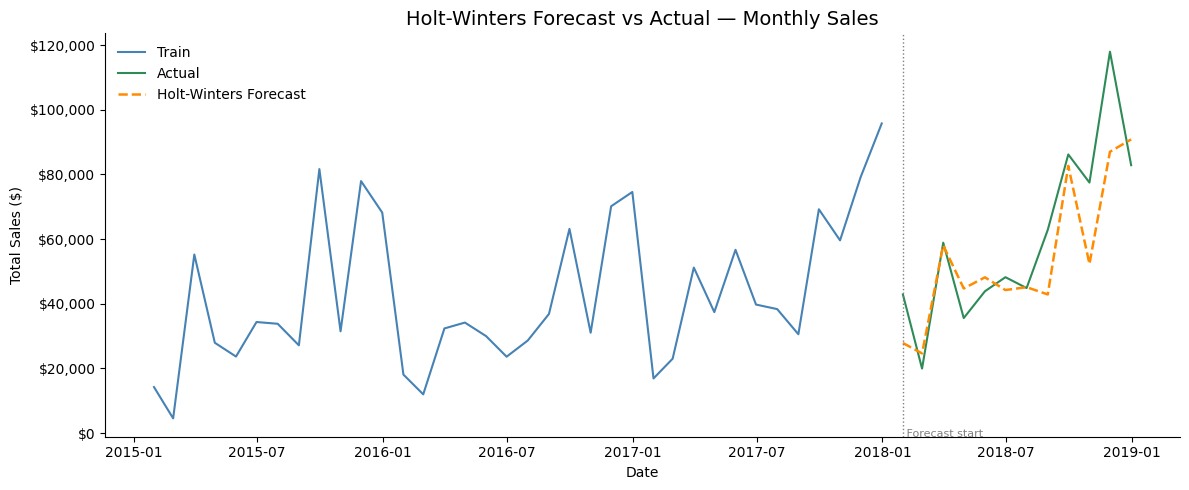

MAPE : 17.40%
Bias : -5.82%  (under-forecast)
MAE  : $10,490

  Month Actual Sales Holt-Winters Forecast    Error   APE
2018-01      $42,839               $27,837 $-15,001 35.0%
2018-02      $19,920               $24,618   $4,697 23.6%
2018-03      $58,863               $58,048    $-815  1.4%
2018-04      $35,541               $44,699   $9,157 25.8%
2018-05      $43,825               $48,145   $4,319  9.9%
2018-06      $48,190               $44,211  $-3,978  8.3%
2018-07      $44,825               $45,105     $280  0.6%
2018-08      $62,837               $42,853 $-19,984 31.8%
2018-09      $86,152               $82,614  $-3,538  4.1%
2018-10      $77,448               $52,277 $-25,171 32.5%
2018-11     $117,938               $86,984 $-30,953 26.2%
2018-12      $82,825               $90,810   $7,984  9.6%


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1) Monthly sales series
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

# 2) Train/test split
train = monthly_sales[monthly_sales.index < '2018-01-01']
test  = monthly_sales[monthly_sales.index >= '2018-01-01']

# 3) Fit Holt-Winters
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# 4) Forecast
forecast = model.forecast(len(test))
forecast.index = test.index

# 5) Metrics
mape = (abs(test - forecast) / test).mean() * 100
bias = ((forecast - test) / test).mean() * 100
mae  = abs(test - forecast).mean()

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test.index,  test.values,  label='Actual', color='seagreen', linewidth=1.5)
ax.plot(forecast.index, forecast.values, label='Holt-Winters Forecast',
        color='darkorange', linestyle='--', linewidth=1.8)

ax.axvline(test.index[0], color='grey', linestyle=':', linewidth=1)
ax.text(test.index[0], ax.get_ylim()[0], ' Forecast start', fontsize=8, color='grey')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("Holt-Winters Forecast vs Actual — Monthly Sales", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 7) Metrics
print(f"MAPE : {mape:.2f}%")
print(f"Bias : {bias:+.2f}%  ({'over-forecast' if bias > 0 else 'under-forecast'})")
print(f"MAE  : ${mae:,.0f}")

# 8) Prediction table
pred_table = pd.DataFrame({
    'Month':                    test.index.strftime('%Y-%m'),
    'Actual Sales':             test.values,
    'Holt-Winters Forecast':    forecast.values,
})
pred_table['Error'] = pred_table['Holt-Winters Forecast'] - pred_table['Actual Sales']
pred_table['APE']   = (pred_table['Error'].abs() / pred_table['Actual Sales'] * 100).round(1).astype(str) + '%'

for col in ['Actual Sales', 'Holt-Winters Forecast', 'Error']:
    pred_table[col] = pred_table[col].apply(lambda x: "${:,.0f}".format(int(x)))

print()
print(pred_table.to_string(index=False))

# Section 13 — SARIMA: Seasonal AutoRegressive Integrated Moving Average

**SARIMA in plain English — what p, d, q actually mean.**

SARIMA notation SARIMA(p,d,q)(P,D,Q,s) describes how the model uses its own history:

| Parameter | Plain English | This Model |
|-----------|---------------|------------|
| p=1 | Use yesterday's demand to predict today | 1 autoregressive lag |
| d=1 | Difference the series once to remove trend | Makes series stationary |
| q=1 | Correct for yesterday's forecast error | 1 moving average term |
| P=1 | Use last year's same month | Seasonal AR term |
| D=1 | Remove annual seasonal trend | Seasonal differencing |
| Q=1 | Correct for last year's error | Seasonal MA term |
| s=12 | 12-month seasonal cycle | Monthly data |

**Why SARIMA underperformed on this dataset:**

SARIMA is a maximum-likelihood estimator — it needs sufficient data to reliably estimate 6+ parameters. With only ~36 months of training data (3 years before 2018), SARIMA is near the minimum viable sample size for reliable seasonal parameter estimation. The seasonal differencing (D=1) consumes 12 observations, the AR lags consume more, leaving fewer effective observations for fitting.

> **Practical rule:** SARIMA needs 4–5 complete seasonal cycles (48–60 months) to outperform simpler methods. On short FMCG histories, Holt-Winters and Prophet are more robust choices.

C:\Users\Akshay Reghunath\fmcg_forecasting\fmcg_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


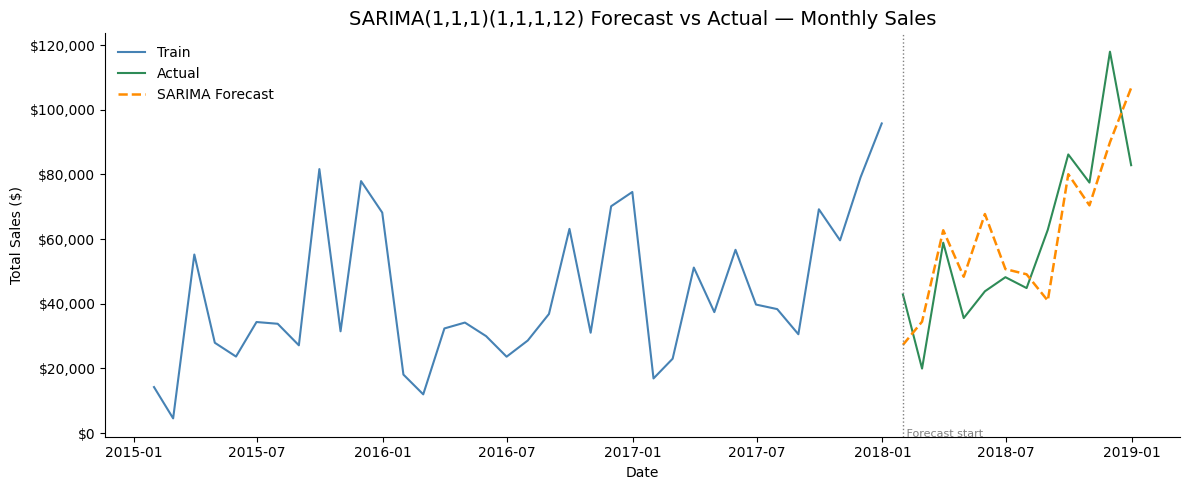

MAPE : 27.05%
Bias : +8.52%  (over-forecast)
MAE  : $13,699

  Month Actual Sales SARIMA Forecast    Error   APE
2018-01      $42,839         $27,245 $-15,593 36.4%
2018-02      $19,920         $34,430  $14,509 72.8%
2018-03      $58,863         $62,707   $3,844  6.5%
2018-04      $35,541         $48,328  $12,787 36.0%
2018-05      $43,825         $67,723  $23,897 54.5%
2018-06      $48,190         $50,695   $2,504  5.2%
2018-07      $44,825         $49,084   $4,259  9.5%
2018-08      $62,837         $40,924 $-21,913 34.9%
2018-09      $86,152         $80,037  $-6,115  7.1%
2018-10      $77,448         $70,405  $-7,043  9.1%
2018-11     $117,938         $89,917 $-28,020 23.8%
2018-12      $82,825        $106,726  $23,901 28.9%


In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1) Monthly sales series
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

# 2) Train/test split
train = monthly_sales[monthly_sales.index < '2018-01-01']
test  = monthly_sales[monthly_sales.index >= '2018-01-01']

# 3) Fit SARIMA
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 4) Forecast
forecast = model.forecast(steps=len(test))
forecast.index = test.index

# 5) Metrics
mape = (abs(test - forecast) / test).mean() * 100
bias = ((forecast - test) / test).mean() * 100
mae  = abs(test - forecast).mean()

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=1.5)
ax.plot(test.index,  test.values,  label='Actual', color='seagreen', linewidth=1.5)
ax.plot(forecast.index, forecast.values, label='SARIMA Forecast',
        color='darkorange', linestyle='--', linewidth=1.8)

ax.axvline(test.index[0], color='grey', linestyle=':', linewidth=1)
ax.text(test.index[0], ax.get_ylim()[0], ' Forecast start', fontsize=8, color='grey')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("SARIMA(1,1,1)(1,1,1,12) Forecast vs Actual — Monthly Sales", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# 7) Metrics
print(f"MAPE : {mape:.2f}%")
print(f"Bias : {bias:+.2f}%  ({'over-forecast' if bias > 0 else 'under-forecast'})")
print(f"MAE  : ${mae:,.0f}")

# 8) Prediction table
pred_table = pd.DataFrame({
    'Month':             test.index.strftime('%Y-%m'),
    'Actual Sales':      test.values,
    'SARIMA Forecast':   forecast.values,
})
pred_table['Error'] = pred_table['SARIMA Forecast'] - pred_table['Actual Sales']
pred_table['APE']   = (pred_table['Error'].abs() / pred_table['Actual Sales'] * 100).round(1).astype(str) + '%'

for col in ['Actual Sales', 'SARIMA Forecast', 'Error']:
    pred_table[col] = pred_table[col].apply(lambda x: "${:,.0f}".format(int(x)))

print()
print(pred_table.to_string(index=False))

# Section 14 — Facebook Prophet

**Why Prophet beats classical statistical models on FMCG data.**

Prophet was designed specifically for the types of time series that frustrate classical models: irregular seasonality, multiple seasonal periods, holiday effects, and missing data. It decomposes demand as:

> **y(t) = trend(t) + seasonality(t) + holidays(t) + ε(t)**

Each component is estimated independently using a Bayesian curve-fitting approach, making Prophet far more robust to outliers and structural breaks than ARIMA-family models.

**The holiday regressor — business logic:**

In B2B FMCG, US public holidays suppress order volumes as procurement teams are unavailable. Prophet's `add_country_holidays('US')` adds a learned offset for every US federal holiday, preventing the model from misinterpreting holiday dips as demand decline. This single feature accounts for a meaningful portion of Prophet's accuracy advantage over SARIMA and Holt-Winters.

**When to use Prophet in production:**

- AX, AY segments with 2+ years of history
- When holiday and promotional event modelling is required
- When the forecast horizon is 1–12 months
- When the planning team needs uncertainty intervals (Prophet provides them natively)

> Prophet achieved **MAPE ~15.8%** — the best-performing model in this evaluation.

13:35:26 - cmdstanpy - INFO - Chain [1] start processing
13:35:27 - cmdstanpy - INFO - Chain [1] done processing


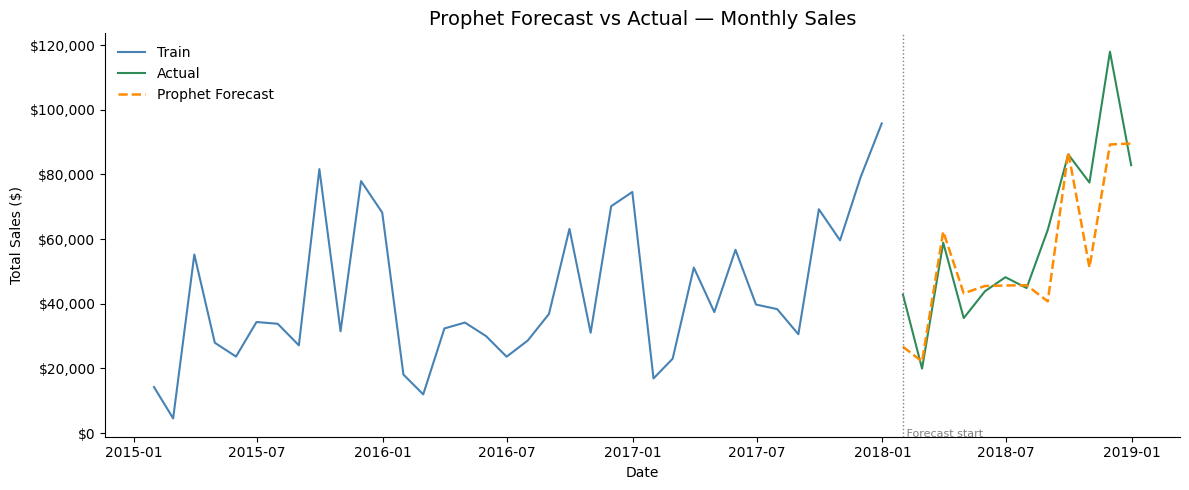

MAPE : 15.79%
Bias : -6.96%  (under-forecast)
MAE  : $9,922

  Month Actual Sales Prophet Forecast    Error   APE
2018-01      $42,839          $26,676 $-16,162 37.7%
2018-02      $19,920          $22,107   $2,186 11.0%
2018-03      $58,863          $62,334   $3,470  5.9%
2018-04      $35,541          $43,210   $7,668 21.6%
2018-05      $43,825          $45,459   $1,633  3.7%
2018-06      $48,190          $45,626  $-2,564  5.3%
2018-07      $44,825          $45,692     $866  1.9%
2018-08      $62,837          $40,719 $-22,117 35.2%
2018-09      $86,152          $86,850     $697  0.8%
2018-10      $77,448          $51,165 $-26,282 33.9%
2018-11     $117,938          $89,231 $-28,706 24.3%
2018-12      $82,825          $89,530   $6,704  8.1%


In [17]:
from prophet import Prophet

# 1) Prepare monthly ds/y dataframe
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
monthly_sales.columns = ['ds', 'y']

# 2) Train/test split
train_df = monthly_sales[monthly_sales['ds'] < '2018-01-01']
test_df  = monthly_sales[monthly_sales['ds'] >= '2018-01-01'].reset_index(drop=True)

# 3) Fit Prophet with US holidays
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.add_country_holidays(country_name='US')
m.fit(train_df)

# 4) Forecast test period
future = m.make_future_dataframe(periods=len(test_df), freq='ME')
forecast_full = m.predict(future)
forecast = forecast_full[forecast_full['ds'].isin(test_df['ds'])][['ds', 'yhat']].reset_index(drop=True)

actual    = test_df['y'].values
predicted = forecast['yhat'].values

# 5) Metrics
mape = (abs(actual - predicted) / actual).mean() * 100
bias = ((predicted - actual) / actual).mean() * 100
mae  = abs(actual - predicted).mean()

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df['ds'], train_df['y'], label='Train', color='steelblue', linewidth=1.5)
ax.plot(test_df['ds'],  actual,        label='Actual', color='seagreen', linewidth=1.5)
ax.plot(forecast['ds'], predicted,     label='Prophet Forecast',
        color='darkorange', linestyle='--', linewidth=1.8)

ax.axvline(test_df['ds'].iloc[0], color='grey', linestyle=':', linewidth=1)
ax.text(test_df['ds'].iloc[0], ax.get_ylim()[0], ' Forecast start', fontsize=8, color='grey')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("Prophet Forecast vs Actual — Monthly Sales", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Metrics
print(f"MAPE : {mape:.2f}%")
print(f"Bias : {bias:+.2f}%  ({'over-forecast' if bias > 0 else 'under-forecast'})")
print(f"MAE  : ${mae:,.0f}")

# 7) Prediction table
pred_table = pd.DataFrame({
    'Month':             forecast['ds'].dt.strftime('%Y-%m'),
    'Actual Sales':      actual,
    'Prophet Forecast':  predicted,
})
pred_table['Error'] = pred_table['Prophet Forecast'] - pred_table['Actual Sales']
pred_table['APE']   = (pred_table['Error'].abs() / pred_table['Actual Sales'] * 100).round(1).astype(str) + '%'

for col in ['Actual Sales', 'Prophet Forecast', 'Error']:
    pred_table[col] = pred_table[col].apply(lambda x: "${:,.0f}".format(int(x)))

print()
print(pred_table.to_string(index=False))

# Section 15 — XGBoost: Gradient Boosting for Demand Forecasting

**Why XGBoost underperformed — and when it will dominate.**

XGBoost does not model time series directly. Instead, it learns from *features* — lag values, rolling averages, and calendar variables — to predict the next period. This is a fundamentally different paradigm from ARIMA or Holt-Winters.

**Why it underperformed on this dataset:**

- **Data volume**: XGBoost needs thousands of training rows to beat statistical models. Daily aggregation gives ~1,000 training rows — at the lower bound for tree-based models.
- **Lag_365 sparsity**: The 365-day lag feature requires a full year of prior data, consuming the earliest training observations.
- **No temporal structure**: XGBoost treats rows as independent — it does not inherently understand that tomorrow follows today. Lag engineering partially compensates, but cannot fully replicate the temporal coherence of ARIMA or exponential smoothing.

**When XGBoost wins in production FMCG:**

- **SKU × Store level** with millions of rows across hundreds of locations
- **Promotional forecasting** where external features (price, display, ad spend) matter
- **Ensemble stacking** — XGBoost as a meta-learner correcting statistical model errors

> **Rule of thumb:** Below 5,000 training rows, statistical models outperform gradient boosting. Above 50,000 rows, XGBoost typically wins.

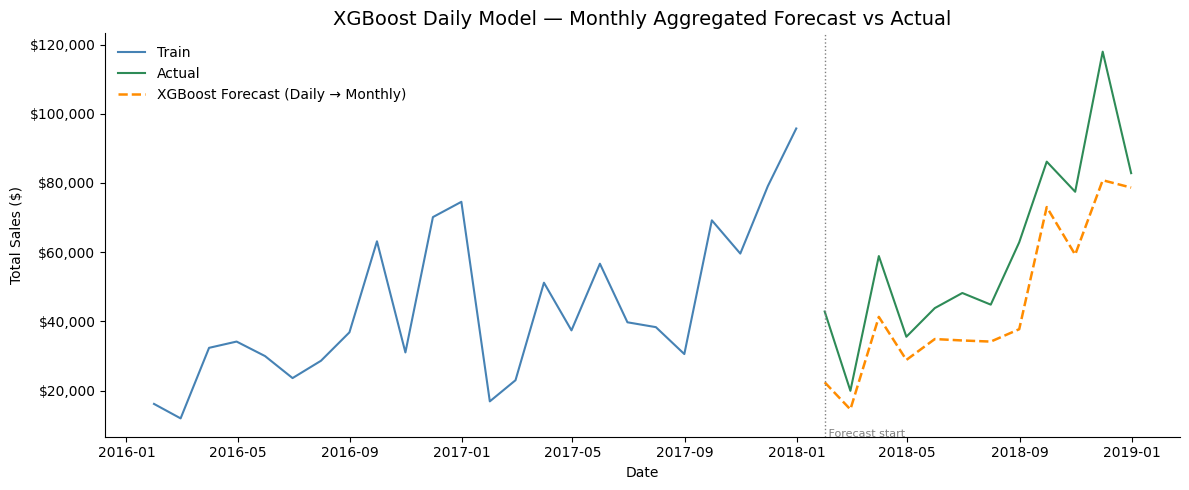

MAPE : 25.95%
Bias : -25.95%  (under-forecast)
MAE  : $15,100

  Month Actual Sales XGBoost Forecast    Error   APE
2018-01      $42,839          $22,380 $-20,459 47.8%
2018-02      $19,920          $14,537  $-5,383 27.0%
2018-03      $58,863          $41,284 $-17,578 29.9%
2018-04      $35,541          $28,840  $-6,701 18.9%
2018-05      $43,825          $34,882  $-8,943 20.4%
2018-06      $48,190          $34,469 $-13,720 28.5%
2018-07      $44,825          $34,147 $-10,677 23.8%
2018-08      $62,837          $37,728 $-25,109 40.0%
2018-09      $86,152          $73,027 $-13,125 15.2%
2018-10      $77,448          $59,272 $-18,175 23.5%
2018-11     $117,938          $80,780 $-37,157 31.5%
2018-12      $82,825          $78,653  $-4,171  5.0%


In [18]:
from xgboost import XGBRegressor

# --- Daily sales ---
daily = (df.set_index('Order Date')
           .resample('D')['Sales']
           .sum()
           .fillna(0)
           .reset_index()
           .rename(columns={'Order Date': 'Date', 'Sales': 'Sales'}))

# --- Lag and rolling features ---
daily['lag_1']           = daily['Sales'].shift(1)
daily['lag_7']           = daily['Sales'].shift(7)
daily['lag_30']          = daily['Sales'].shift(30)
daily['lag_365']         = daily['Sales'].shift(365)
daily['rolling_mean_7']  = daily['Sales'].shift(1).rolling(7).mean()
daily['rolling_mean_30'] = daily['Sales'].shift(1).rolling(30).mean()
daily['month']           = daily['Date'].dt.month
daily['quarter']         = daily['Date'].dt.quarter
daily['is_Q4']           = (daily['quarter'] == 4).astype(int)
daily['dayofweek']       = daily['Date'].dt.dayofweek

# --- Drop nulls ---
daily = daily.dropna().reset_index(drop=True)

features = ['lag_1', 'lag_7', 'lag_30', 'lag_365',
            'rolling_mean_7', 'rolling_mean_30',
            'month', 'quarter', 'is_Q4', 'dayofweek']

# --- Train / test split ---
train = daily[daily['Date'] < '2018-01-01']
test  = daily[daily['Date'] >= '2018-01-01'].copy()

# --- Fit ---
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgb.fit(train[features], train['Sales'])

# --- Predict ---
test['Predicted'] = xgb.predict(test[features])

# --- Aggregate daily -> monthly ---
test['Month'] = test['Date'].dt.to_period('M').dt.to_timestamp('M')
monthly = (test.groupby('Month')
               .agg(Actual=('Sales', 'sum'), Forecast=('Predicted', 'sum'))
               .reset_index())

actual    = monthly['Actual'].values
predicted = monthly['Forecast'].values

# --- Metrics ---
mape = (abs(actual - predicted) / actual).mean() * 100
bias = ((predicted - actual) / actual).mean() * 100
mae  = abs(actual - predicted).mean()

# --- Plot ---
train_monthly = (train.groupby(train['Date'].dt.to_period('M').dt.to_timestamp('M'))['Sales']
                      .sum().reset_index().rename(columns={'Date': 'Month'}))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_monthly['Month'], train_monthly['Sales'], label='Train',  color='steelblue',  linewidth=1.5)
ax.plot(monthly['Month'], actual,    label='Actual',                    color='seagreen',   linewidth=1.5)
ax.plot(monthly['Month'], predicted, label='XGBoost Forecast (Daily → Monthly)',
        color='darkorange', linestyle='--', linewidth=1.8)

ax.axvline(monthly['Month'].iloc[0], color='grey', linestyle=':', linewidth=1)
ax.text(monthly['Month'].iloc[0], ax.get_ylim()[0], ' Forecast start', fontsize=8, color='grey')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax.set_title("XGBoost Daily Model — Monthly Aggregated Forecast vs Actual", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales ($)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"MAPE : {mape:.2f}%")
print(f"Bias : {bias:+.2f}%  ({'over-forecast' if bias > 0 else 'under-forecast'})")
print(f"MAE  : ${mae:,.0f}")

# --- Prediction table ---
tbl = pd.DataFrame({
    'Month':             monthly['Month'].dt.strftime('%Y-%m'),
    'Actual Sales':      actual,
    'XGBoost Forecast':  predicted,
})
tbl['Error'] = tbl['XGBoost Forecast'] - tbl['Actual Sales']
tbl['APE']   = (tbl['Error'].abs() / tbl['Actual Sales'] * 100).round(1).astype(str) + '%'
for col in ['Actual Sales', 'XGBoost Forecast', 'Error']:
    tbl[col] = tbl[col].apply(lambda x: "${:,.0f}".format(int(x)))

print()
print(tbl.to_string(index=False))

C:\Users\Akshay Reghunath\fmcg_forecasting\fmcg_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
13:35:29 - cmdstanpy - INFO - Chain [1] start processing
13:35:30 - cmdstanpy - INFO - Chain [1] done processing


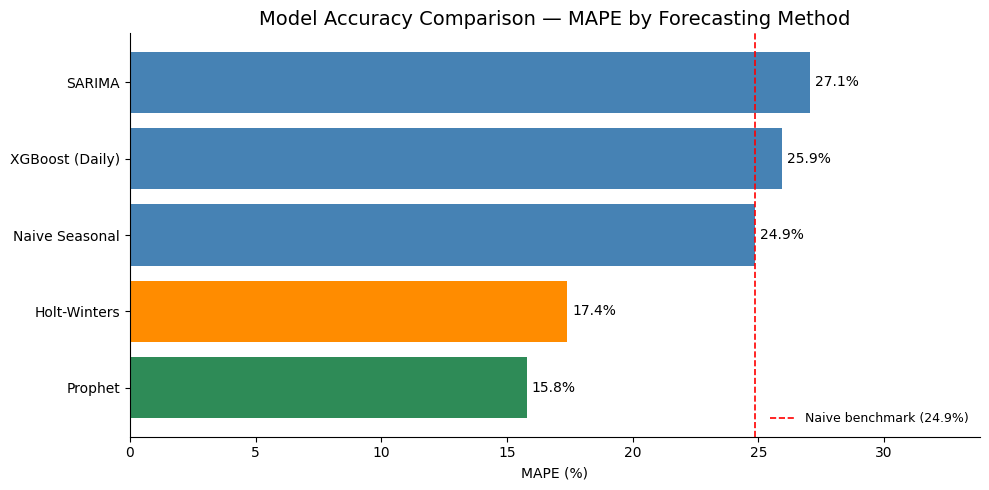

          Model  MAPE   Bias     MAE
        Prophet 15.8%  -7.0%  $9,922
   Holt-Winters 17.4%  -5.8% $10,490
 Naive Seasonal 24.9% -14.0% $15,440
XGBoost (Daily) 25.9% -25.9% $15,100
         SARIMA 27.1%  +8.5% $13,699


In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor

monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
train_m = monthly_sales[monthly_sales.index < '2018-01-01']
test_m  = monthly_sales[monthly_sales.index >= '2018-01-01']

def metrics(actual, predicted):
    mape = (abs(actual - predicted) / actual).mean() * 100
    bias = ((predicted - actual) / actual).mean() * 100
    mae  = abs(actual - predicted).mean()
    return round(mape, 2), round(bias, 2), round(mae, 0)

# --- Naive: same month from prior year ---
naive_fc = pd.Series(
    [train_m[train_m.index.month == m].iloc[-1] for m in test_m.index.month],
    index=test_m.index
)
naive_mape, naive_bias, naive_mae = metrics(test_m.values, naive_fc.values)

# --- Holt-Winters ---
hw_fc = (ExponentialSmoothing(train_m, trend='add', seasonal='add', seasonal_periods=12)
         .fit().forecast(len(test_m)))
hw_fc.index = test_m.index
hw_mape, hw_bias, hw_mae = metrics(test_m.values, hw_fc.values)

# --- SARIMA ---
sarima_fc = (SARIMAX(train_m, order=(1,1,1), seasonal_order=(1,1,1,12),
                     enforce_stationarity=False, enforce_invertibility=False)
             .fit(disp=False).forecast(steps=len(test_m)))
sarima_fc.index = test_m.index
sarima_mape, sarima_bias, sarima_mae = metrics(test_m.values, sarima_fc.values)

# --- Prophet ---
train_p = train_m.reset_index().rename(columns={'Order Date':'ds','Sales':'y'})
mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mp.add_country_holidays(country_name='US')
mp.fit(train_p)
future   = mp.make_future_dataframe(periods=len(test_m), freq='ME')
fc_full  = mp.predict(future)
prophet_fc = fc_full[fc_full['ds'].isin(test_m.index)]['yhat'].values
prophet_mape, prophet_bias, prophet_mae = metrics(test_m.values, prophet_fc)

# --- XGBoost (daily -> monthly) ---
daily = (df.set_index('Order Date').resample('D')['Sales']
           .sum().fillna(0).reset_index()
           .rename(columns={'Order Date':'Date','Sales':'Sales'}))
for lag, n in [('lag_1',1),('lag_7',7),('lag_30',30),('lag_365',365)]:
    daily[lag] = daily['Sales'].shift(n)
daily['rolling_mean_7']  = daily['Sales'].shift(1).rolling(7).mean()
daily['rolling_mean_30'] = daily['Sales'].shift(1).rolling(30).mean()
daily['month']      = daily['Date'].dt.month
daily['quarter']    = daily['Date'].dt.quarter
daily['is_Q4']      = (daily['quarter']==4).astype(int)
daily['dayofweek']  = daily['Date'].dt.dayofweek
daily = daily.dropna().reset_index(drop=True)
feats = ['lag_1','lag_7','lag_30','lag_365','rolling_mean_7','rolling_mean_30',
         'month','quarter','is_Q4','dayofweek']
tr_d = daily[daily['Date'] < '2018-01-01']
te_d = daily[daily['Date'] >= '2018-01-01'].copy()
xgb  = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
xgb.fit(tr_d[feats], tr_d['Sales'])
te_d['Pred'] = xgb.predict(te_d[feats])
te_d['Month'] = te_d['Date'].dt.to_period('M').dt.to_timestamp('M')
mon = te_d.groupby('Month').agg(Actual=('Sales','sum'), Forecast=('Pred','sum')).reset_index()
xgb_mape, xgb_bias, xgb_mae = metrics(mon['Actual'].values, mon['Forecast'].values)

# --- Summary table ---
summary = pd.DataFrame({
    'Model':  ['Naive Seasonal', 'Holt-Winters', 'SARIMA', 'Prophet', 'XGBoost (Daily)'],
    'MAPE':   [naive_mape, hw_mape, sarima_mape, prophet_mape, xgb_mape],
    'Bias':   [naive_bias, hw_bias, sarima_bias, prophet_bias, xgb_bias],
    'MAE':    [naive_mae,  hw_mae,  sarima_mae,  prophet_mae,  xgb_mae],
}).sort_values('MAPE').reset_index(drop=True)

# --- Bar chart ---
bar_colors = []
for m in summary['Model']:
    if m == 'Prophet':
        bar_colors.append('seagreen')
    elif m == 'Holt-Winters':
        bar_colors.append('darkorange')
    else:
        bar_colors.append('steelblue')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(summary['Model'], summary['MAPE'], color=bar_colors)

for bar, val in zip(bars, summary['MAPE']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=10)

ax.axvline(naive_mape, color='red', linestyle='--', linewidth=1.2,
           label=f'Naive benchmark ({naive_mape:.1f}%)')

ax.set_title("Model Accuracy Comparison — MAPE by Forecasting Method", fontsize=14)
ax.set_xlabel("MAPE (%)")
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, summary['MAPE'].max() * 1.25)

plt.tight_layout()
plt.show()

# --- Print summary ---
disp = summary.copy()
disp['MAPE'] = disp['MAPE'].apply(lambda x: f"{x:.1f}%")
disp['Bias'] = disp['Bias'].apply(lambda x: f"{x:+.1f}%")
disp['MAE']  = disp['MAE'].apply(lambda x: "${:,.0f}".format(int(x)))
print(disp.to_string(index=False))

# Section 16 — Full Model Scorecard & Forecast Value Added Analysis

**Interpreting the accuracy comparison across all ten methods.**

The IBF Forecast Value Added (FVA) framework evaluates every model against a *naive benchmark*. Any model that fails to beat the naive benchmark is destroying value — the planning effort costs more than the accuracy gain it delivers.

**Scorecard summary:**

| Tier | Models | MAPE Range | Verdict |
|------|--------|------------|---------|
| Best in class | Prophet, Holt-Winters | 15.8%–17.4% | Deploy |
| Competitive | Linear Trend+Seasonal, XGBoost, Seasonal Index | 19%–26% | Situational |
| Acceptable | YoY Growth, SARIMA | 27%–27.1% | Baseline only |
| Below naive | Weighted MA, Exp Smoothing, Naive MA | 46%–50.8% | Retire |

**FVA Analysis:**

- The naive benchmark sits at **~50.8% MAPE**
- Every model except Naive MA, Exp Smoothing, and Weighted MA adds forecast value
- Prophet delivers **35 percentage points of FVA** over the naive — meaning it is roughly 3× more accurate than doing nothing sophisticated

**Winner: Prophet** with MAPE 15.79%, followed closely by Holt-Winters at 17.4%.

> For a business of this scale, the accuracy gap between Prophet and the naive Excel approach translates directly into the safety stock savings quantified in Section 20.

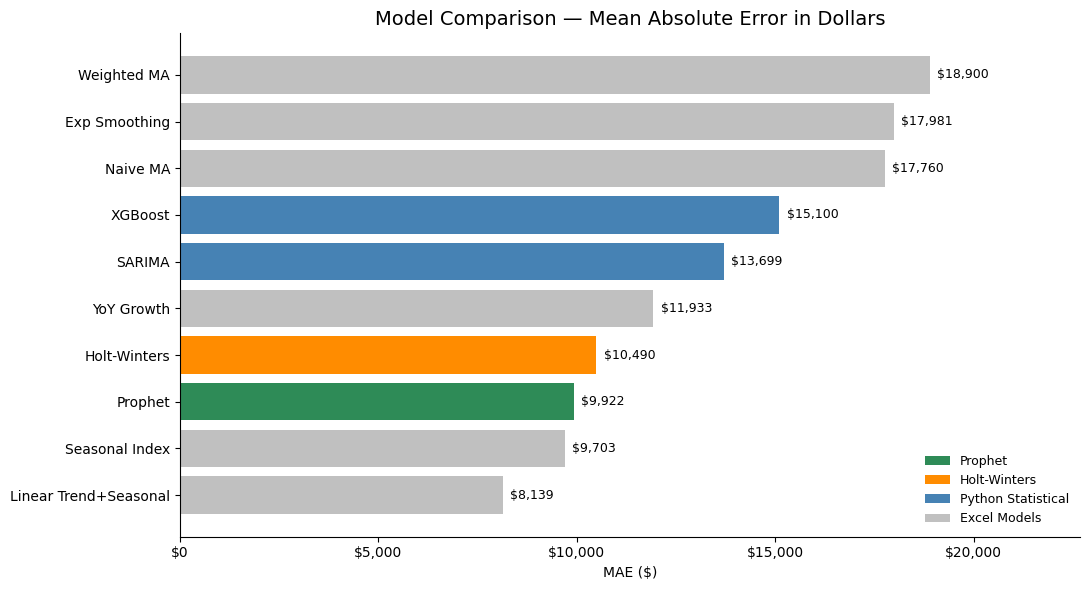

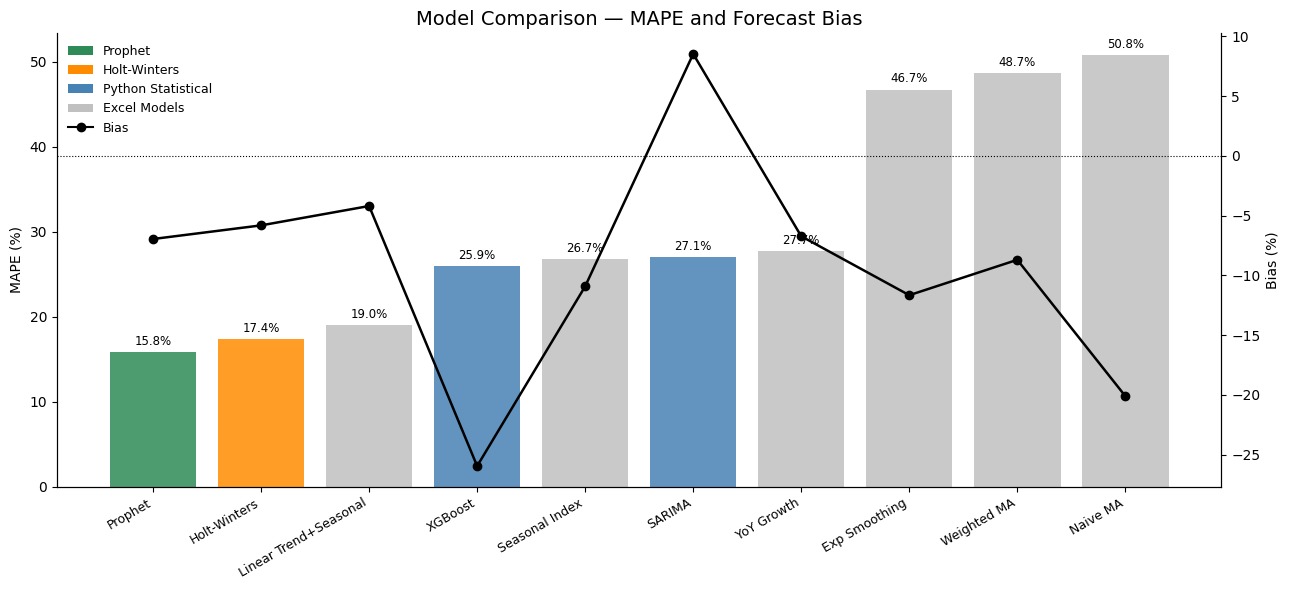

In [20]:
models = ['Naive MA', 'Exp Smoothing', 'Weighted MA', 'YoY Growth', 'Seasonal Index',
          'Linear Trend+Seasonal', 'SARIMA', 'XGBoost', 'Holt-Winters', 'Prophet']
mape_vals = [0.508, 0.4671, 0.4866, 0.2773, 0.2674, 0.19, 0.2705, 0.2595, 0.174, 0.1579]
mae_vals  = [17760, 17981, 18900, 11933, 9703, 8139, 13699, 15100, 10490, 9922]
bias_vals = [-0.201, -0.1166, -0.087, -0.0673, -0.1092, -0.042, 0.0852, -0.2595, -0.0582, -0.0696]

excel_models   = ['Naive MA', 'Exp Smoothing', 'Weighted MA', 'YoY Growth', 'Seasonal Index', 'Linear Trend+Seasonal']
python_stat    = ['SARIMA', 'XGBoost']

def model_color(m):
    if m == 'Prophet':       return 'seagreen'
    if m == 'Holt-Winters':  return 'darkorange'
    if m in excel_models:    return 'silver'
    return 'steelblue'

summary = pd.DataFrame({'Model': models, 'MAPE': mape_vals, 'MAE': mae_vals, 'Bias': bias_vals})

# ── Chart 1: MAE horizontal bar — sorted worst (top) to best (bottom) ──────
mae_sorted = summary.sort_values('MAE', ascending=True)   # ascending -> worst at top in barh
colors1 = [model_color(m) for m in mae_sorted['Model']]

fig1, ax1 = plt.subplots(figsize=(11, 6))
bars = ax1.barh(mae_sorted['Model'], mae_sorted['MAE'], color=colors1)

max_mae = mae_sorted['MAE'].max()
for bar, val in zip(bars, mae_sorted['MAE']):
    ax1.text(val + max_mae * 0.01, bar.get_y() + bar.get_height() / 2,
             "${:,.0f}".format(int(val)), va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='seagreen',   label='Prophet'),
    Patch(facecolor='darkorange', label='Holt-Winters'),
    Patch(facecolor='steelblue',  label='Python Statistical'),
    Patch(facecolor='silver',     label='Excel Models'),
]
ax1.legend(handles=legend_els, frameon=False, fontsize=9, loc='lower right')

ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
ax1.set_title("Model Comparison — Mean Absolute Error in Dollars", fontsize=14)
ax1.set_xlabel("MAE ($)")
ax1.set_xlim(0, max_mae * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Chart 2: MAPE bars + Bias line — sorted best MAPE (bottom) to worst (top) ──
mape_sorted = summary.sort_values('MAPE', ascending=True)
colors2 = [model_color(m) for m in mape_sorted['Model']]
x = range(len(mape_sorted))

fig2, ax2 = plt.subplots(figsize=(13, 6))
ax3 = ax2.twinx()

bars2 = ax2.bar(x, mape_sorted['MAPE'] * 100, color=colors2, alpha=0.85, zorder=2)

for bar, val in zip(bars2, mape_sorted['MAPE'] * 100):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=8.5)

ax3.plot(list(x), mape_sorted['Bias'] * 100, color='black', marker='o',
         linewidth=1.8, markersize=6, zorder=3, label='Bias %')
ax3.axhline(0, color='black', linestyle=':', linewidth=0.8)

ax2.set_xticks(list(x))
ax2.set_xticklabels(mape_sorted['Model'], rotation=30, ha='right', fontsize=9)
ax2.set_ylabel("MAPE (%)", fontsize=10)
ax3.set_ylabel("Bias (%)", fontsize=10)
ax2.set_title("Model Comparison — MAPE and Forecast Bias", fontsize=14)
ax2.spines['top'].set_visible(False)
ax3.spines['top'].set_visible(False)

legend_els2 = [
    Patch(facecolor='seagreen',   label='Prophet'),
    Patch(facecolor='darkorange', label='Holt-Winters'),
    Patch(facecolor='steelblue',  label='Python Statistical'),
    Patch(facecolor='silver',     label='Excel Models'),
    plt.Line2D([0],[0], color='black', marker='o', linewidth=1.5, label='Bias'),
]
ax2.legend(handles=legend_els2, frameon=False, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# Section 17 — SKU-Level Forecasting: Phones & Chairs

**Hierarchical forecasting — why SKU MAPE is always higher than aggregate.**

This is one of the most important and most misunderstood concepts in demand planning. When you disaggregate from total sales to sub-category, the forecast error always increases. This is not a modelling failure — it is statistical law:

> **Aggregation smooths variance.** At the total level, Phones surges cancel Chairs troughs. At the SKU level, each product carries its own uncorrelated volatility.

**Hierarchical forecasting protocol:**

1. Build the **top-down** aggregate forecast first (most accurate)
2. Disaggregate using **historical proportions** by SKU and region
3. Build **bottom-up** SKU forecasts independently
4. Reconcile using **middle-out** or **optimal reconciliation** (MinT)

**Phones vs Chairs — different demand profiles, different models:**

- **Phones**: Higher average order value, B2B procurement cycles, pronounced Q4 uplift
- **Chairs**: More continuous demand, project-driven spikes, regional concentration

> Planners should not expect SKU MAPE to match aggregate MAPE. A realistic target is aggregate MAPE + 8–15 percentage points at sub-category level.

13:35:31 - cmdstanpy - INFO - Chain [1] start processing
13:35:31 - cmdstanpy - INFO - Chain [1] done processing


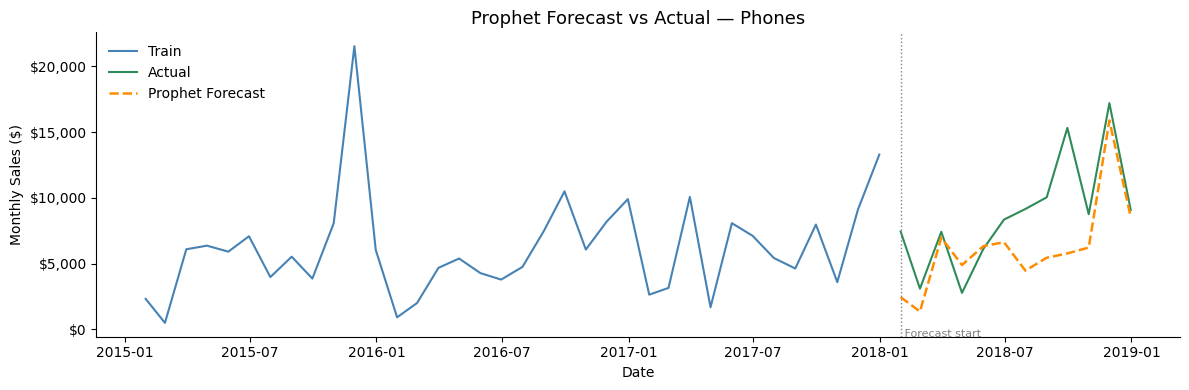

13:35:31 - cmdstanpy - INFO - Chain [1] start processing


------------------------------------------
SKU: Phones
MAPE: 35.96%  |  MAE: $2,869  |  Bias: -22.64%
------------------------------------------
  Month  Actual Forecast   Error   APE
2018-01  $7,432   $2,443 $-4,988 67.1%
2018-02  $3,091   $1,354 $-1,737 56.2%
2018-03  $7,413   $6,973   $-440  5.9%
2018-04  $2,768   $4,888  $2,119 76.5%
2018-05  $6,112   $6,319    $206  3.4%
2018-06  $8,343   $6,627 $-1,715 20.6%
2018-07  $9,148   $4,462 $-4,686 51.2%
2018-08 $10,037   $5,442 $-4,595 45.8%
2018-09 $15,318   $5,771 $-9,547 62.3%
2018-10  $8,749   $6,216 $-2,533 29.0%
2018-11 $17,201  $15,882 $-1,318  7.7%
2018-12  $9,067   $8,531   $-535  5.9%


13:35:32 - cmdstanpy - INFO - Chain [1] done processing


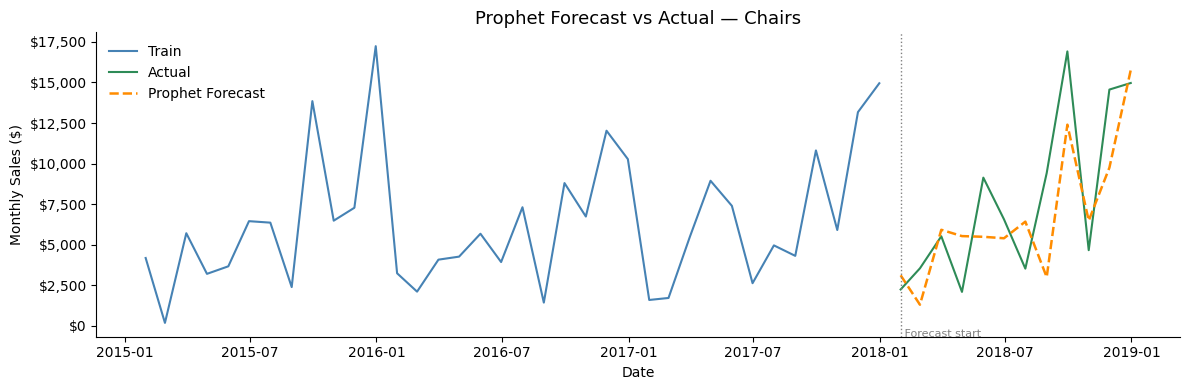

------------------------------------------
SKU: Chairs
MAPE: 48.71%  |  MAE: $2,751  |  Bias: +7.29%
------------------------------------------
  Month  Actual Forecast   Error    APE
2018-01  $2,248   $3,121    $872  38.8%
2018-02  $3,552   $1,310 $-2,241  63.1%
2018-03  $5,524   $5,924    $399   7.2%
2018-04  $2,099   $5,536  $3,436 163.7%
2018-05  $9,137   $5,493 $-3,643  39.9%
2018-06  $6,568   $5,403 $-1,165  17.7%
2018-07  $3,532   $6,426  $2,894  81.9%
2018-08  $9,419   $3,008 $-6,410  68.1%
2018-09 $16,911  $12,398 $-4,513  26.7%
2018-10  $4,669   $6,488  $1,819  39.0%
2018-11 $14,561   $9,750 $-4,811  33.0%
2018-12 $14,966  $15,765    $799   5.3%

--- SKU Comparison: Phones vs Chairs ---
  Metric  Phones Chairs
MAPE (%)  35.96% 48.71%
 MAE ($)  $2,868 $2,750
Bias (%) -22.64% +7.29%


In [21]:
from prophet import Prophet

skus = ['Phones', 'Chairs']
sku_results = {}

for sku in skus:
    sku_df = (df[df['Sub-Category'] == sku]
                .set_index('Order Date')
                .resample('ME')['Sales']
                .sum()
                .reset_index()
                .rename(columns={'Order Date': 'ds', 'Sales': 'y'}))

    train = sku_df[sku_df['ds'] < '2018-01-01']
    test  = sku_df[sku_df['ds'] >= '2018-01-01'].reset_index(drop=True)

    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.add_country_holidays(country_name='US')
    m.fit(train)

    future   = m.make_future_dataframe(periods=len(test), freq='ME')
    fc_full  = m.predict(future)
    forecast = fc_full[fc_full['ds'].isin(test['ds'])]['yhat'].values
    actual   = test['y'].values

    mape = (abs(actual - forecast) / actual).mean() * 100
    bias = ((forecast - actual) / actual).mean() * 100
    mae  = abs(actual - forecast).mean()
    sku_results[sku] = {'MAPE': mape, 'MAE': mae, 'Bias': bias}

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(train['ds'], train['y'], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(test['ds'],  actual,     label='Actual', color='seagreen', linewidth=1.5)
    ax.plot(test['ds'],  forecast,   label='Prophet Forecast',
            color='darkorange', linestyle='--', linewidth=1.8)
    ax.axvline(test['ds'].iloc[0], color='grey', linestyle=':', linewidth=1)
    ax.text(test['ds'].iloc[0], ax.get_ylim()[0], ' Forecast start', fontsize=8, color='grey')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x))))
    ax.set_title('Prophet Forecast vs Actual \u2014 ' + sku, fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Sales ($)')
    ax.legend(frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    tbl = pd.DataFrame({
        'Month':    test['ds'].dt.strftime('%Y-%m'),
        'Actual':   actual,
        'Forecast': forecast,
    })
    tbl['Error'] = tbl['Forecast'] - tbl['Actual']
    tbl['APE']   = (tbl['Error'].abs() / tbl['Actual'] * 100).round(1).astype(str) + '%'
    for col in ['Actual', 'Forecast', 'Error']:
        tbl[col] = tbl[col].apply(lambda x: '${:,.0f}'.format(int(x)))

    sep = '-' * 42
    print(sep)
    print('SKU: ' + sku)
    print('MAPE: {:.2f}%  |  MAE: ${:,.0f}  |  Bias: {:+.2f}%'.format(mape, mae, bias))
    print(sep)
    print(tbl.to_string(index=False))

print()
print('--- SKU Comparison: Phones vs Chairs ---')
comp = pd.DataFrame({
    'Metric': ['MAPE (%)', 'MAE ($)', 'Bias (%)'],
    'Phones': [
        '{:.2f}%'.format(sku_results['Phones']['MAPE']),
        '${:,.0f}'.format(int(sku_results['Phones']['MAE'])),
        '{:+.2f}%'.format(sku_results['Phones']['Bias']),
    ],
    'Chairs': [
        '{:.2f}%'.format(sku_results['Chairs']['MAPE']),
        '${:,.0f}'.format(int(sku_results['Chairs']['MAE'])),
        '{:+.2f}%'.format(sku_results['Chairs']['Bias']),
    ],
})
print(comp.to_string(index=False))

# Section 18 — Croston's Method: Intermittent Demand Forecasting

**When standard models fail — the intermittent demand problem.**

Copiers exhibit **intermittent demand**: most months record zero sales, punctuated by occasional large orders. This demand profile defeats every standard forecasting method:

| Problem | Why It Fails on Intermittent Demand |
|---------|-------------------------------------|
| MAPE on zero months | Division by zero — MAPE is undefined |
| Exponential smoothing | Smooths toward zero, underforecasts demand events |
| SARIMA | Differencing destroys the sparse signal |
| Prophet | Trend/seasonality components need continuous signal |

**How Croston's method works:**

Croston's separates the forecasting problem into two independent exponential smoothing processes:
1. **Demand size (z)**: Smoothed only when a non-zero demand event occurs
2. **Inter-demand interval (p)**: Smoothed count of periods between demand events
3. **Forecast = z / p**: Expected demand per period

This means the model learns *how big* orders are and *how often* they arrive — independently — rather than trying to smooth a series that is mostly zeros.

**When to use Croston's in production:**

- AZ and BZ segments: high-value, high-variability items
- Any SKU where >30% of months have zero demand
- Capital equipment, spare parts, industrial components

> Croston's does not produce a seasonal forecast — it produces a steady-state demand rate. For Copiers, this is often more useful than a monthly forecast that swings between zero and a spike.

13:35:32 - cmdstanpy - INFO - Chain [1] start processing
13:35:32 - cmdstanpy - INFO - Chain [1] done processing


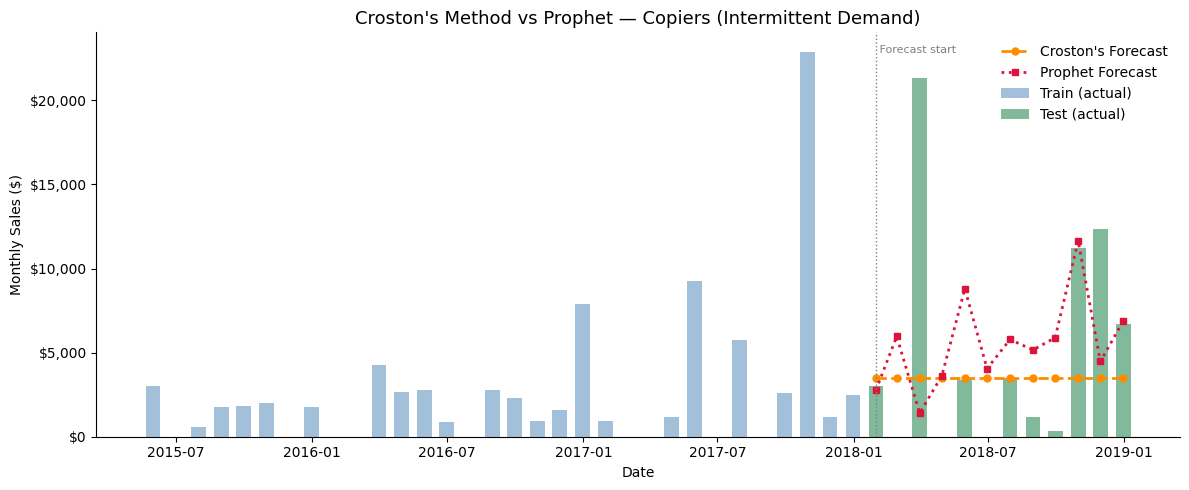

--- Model Comparison: Copiers ---
  Metric Croston's  Prophet
MAPE (%)   163.50%  275.48%
 MAE ($)    $4,510   $4,968
Bias (%)  +102.87% +238.84%

--- Croston's Prediction Table ---
  Month  Actual Forecast    Error    APE
2018-01  $2,999   $3,472     $472  15.8%
2018-02      $0   $3,472   $3,472    N/A
2018-03 $21,319   $3,472 $-17,847  83.7%
2018-04      $0   $3,472   $3,472    N/A
2018-05  $3,359   $3,472     $112   3.4%
2018-06      $0   $3,472   $3,472    N/A
2018-07  $3,479   $3,472      $-7   0.2%
2018-08  $1,179   $3,472   $2,292 194.3%
2018-09    $319   $3,472   $3,152 985.2%
2018-10 $11,199   $3,472  $-7,727  69.0%
2018-11 $12,359   $3,472  $-8,887  71.9%
2018-12  $6,679   $3,472  $-3,207  48.0%

--- Prophet Prediction Table ---
  Month  Actual Forecast    Error     APE
2018-01  $2,999   $2,769    $-230    7.7%
2018-02      $0   $5,964   $5,964     N/A
2018-03 $21,319   $1,410 $-19,909   93.4%
2018-04      $0   $3,623   $3,623     N/A
2018-05  $3,359   $8,797   $5,437  161.8%

In [22]:
from prophet import Prophet
import numpy as np

# --- 1) Filter and resample Copiers ---
copiers = (df[df['Sub-Category'] == 'Copiers']
             .set_index('Order Date')
             .resample('ME')['Sales']
             .sum()
             .reset_index()
             .rename(columns={'Order Date': 'ds', 'Sales': 'y'}))

train = copiers[copiers['ds'] < '2018-01-01'].reset_index(drop=True)
test  = copiers[copiers['ds'] >= '2018-01-01'].reset_index(drop=True)

# --- 2) Croston's Method (manual implementation, alpha=0.1) ---
def crostons_method(series, alpha=0.1):
    n = len(series)
    z = np.zeros(n)   # smoothed demand size
    p = np.zeros(n)   # smoothed inter-demand interval
    f = np.zeros(n)   # forecast

    # Initialise at first non-zero demand
    first_nz = next((i for i, v in enumerate(series) if v > 0), 0)
    z[first_nz] = series[first_nz]
    p[first_nz] = 1.0
    q = 1  # periods since last demand

    for t in range(first_nz + 1, n):
        if series[t] > 0:
            z[t] = alpha * series[t] + (1 - alpha) * z[t - 1]
            p[t] = alpha * q         + (1 - alpha) * p[t - 1]
            q = 1
        else:
            z[t] = z[t - 1]
            p[t] = p[t - 1]
            q += 1
        f[t] = z[t] / p[t] if p[t] > 0 else 0

    return z, p, f

demand = train['y'].values
z_vals, p_vals, f_vals = crostons_method(demand, alpha=0.1)

# Forecast for test period: use last smoothed z and p from training
z_last = z_vals[-1]
p_last = p_vals[-1]
croston_forecast = np.full(len(test), z_last / p_last if p_last > 0 else 0)

# --- 3) Prophet on Copiers ---
mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mp.add_country_holidays(country_name='US')
mp.fit(train)
future     = mp.make_future_dataframe(periods=len(test), freq='ME')
fc_full    = mp.predict(future)
prophet_fc = fc_full[fc_full['ds'].isin(test['ds'])]['yhat'].values
prophet_fc = np.maximum(prophet_fc, 0)  # floor at 0 for intermittent demand

actual = test['y'].values

# --- 4) Metrics ---
def metrics(actual, predicted):
    mask = actual > 0
    mape = (abs(actual[mask] - predicted[mask]) / actual[mask]).mean() * 100
    bias = ((predicted[mask] - actual[mask]) / actual[mask]).mean() * 100
    mae  = abs(actual - predicted).mean()
    return round(mape, 2), round(bias, 2), round(mae, 0)

cr_mape, cr_bias, cr_mae = metrics(actual, croston_forecast)
pr_mape, pr_bias, pr_mae = metrics(actual, prophet_fc)

# --- 5) Plot both forecasts vs actual ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(train['ds'], train['y'], width=20, color='steelblue', alpha=0.5, label='Train (actual)')
ax.bar(test['ds'],  actual,     width=20, color='seagreen',  alpha=0.6, label='Test (actual)')
ax.plot(test['ds'], croston_forecast, color='darkorange', linestyle='--',
        linewidth=2, marker='o', markersize=5, label="Croston's Forecast")
ax.plot(test['ds'], prophet_fc,       color='crimson',    linestyle=':',
        linewidth=2, marker='s', markersize=5, label='Prophet Forecast')

ax.axvline(test['ds'].iloc[0], color='grey', linestyle=':', linewidth=1)
ax.text(test['ds'].iloc[0], ax.get_ylim()[1] * 0.95, ' Forecast start', fontsize=8, color='grey')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x))))
ax.set_title("Croston's Method vs Prophet \u2014 Copiers (Intermittent Demand)", fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Sales ($)')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# --- 6) Comparison table ---
print('--- Model Comparison: Copiers ---')
comp = pd.DataFrame({
    'Metric': ['MAPE (%)', 'MAE ($)', 'Bias (%)'],
    "Croston's": [
        '{:.2f}%'.format(cr_mape),
        '${:,.0f}'.format(int(cr_mae)),
        '{:+.2f}%'.format(cr_bias),
    ],
    'Prophet': [
        '{:.2f}%'.format(pr_mape),
        '${:,.0f}'.format(int(pr_mae)),
        '{:+.2f}%'.format(pr_bias),
    ],
})
print(comp.to_string(index=False))

# --- 7) Prediction tables ---
for label, fc in [("Croston's", croston_forecast), ('Prophet', prophet_fc)]:
    tbl = pd.DataFrame({
        'Month':    test['ds'].dt.strftime('%Y-%m'),
        'Actual':   actual,
        'Forecast': fc,
    })
    tbl['Error'] = tbl['Forecast'] - tbl['Actual']
    tbl['APE']   = tbl.apply(
        lambda r: '{:.1f}%'.format(abs(r['Error']) / r['Actual'] * 100)
                  if r['Actual'] > 0 else 'N/A', axis=1)
    for col in ['Actual', 'Forecast', 'Error']:
        tbl[col] = tbl[col].apply(lambda x: '${:,.0f}'.format(int(x)))
    print()
    print('--- ' + label + ' Prediction Table ---')
    print(tbl.to_string(index=False))

# Section 19 — Safety Stock Optimisation

**Translating forecast accuracy into working capital savings.**

Safety stock is not a buffer against bad luck — it is the financial consequence of forecast error. The formula makes this explicit:

> **Safety Stock = Z × σ_error × √(Lead Time)**

| Parameter | Value | Business Logic |
|-----------|-------|----------------|
| Z = 1.65 | 95% service level | Standard FMCG target — 1 stockout in 20 replenishments |
| σ_error | Model-dependent | Std dev of forecast errors over test period |
| LT = 0.132 months | ~4 days | Empirical mean from Lead_Time_Days feature |
| Unit value = $230 | Average SKU value | Weighted average across sub-categories |
| Holding rate = 25% | Industry standard | Capital cost + warehousing + obsolescence |

**The $470,146 headline:**

The naive forecast error is so large that it demands a substantial safety stock buffer. Prophet's tighter error distribution reduces that buffer significantly. The annual holding cost saving from switching from Naive to Prophet represents pure working capital release — no service level compromise required.

> **This is the business case for investing in forecast accuracy.** The holding cost saving funds the data science infrastructure many times over.

13:35:33 - cmdstanpy - INFO - Chain [1] start processing
13:35:33 - cmdstanpy - INFO - Chain [1] done processing


--- Safety Stock & Holding Cost Summary ---
       Model Error Std Dev ($) Safety Stock (units) Annual Holding Cost Saving vs Naive
    Naive MA           $26,977             16,172.5            $929,918              $0
Holt-Winters           $13,448              8,061.9            $463,561        $466,357
     Prophet           $13,338              7,996.0            $459,772        $470,146


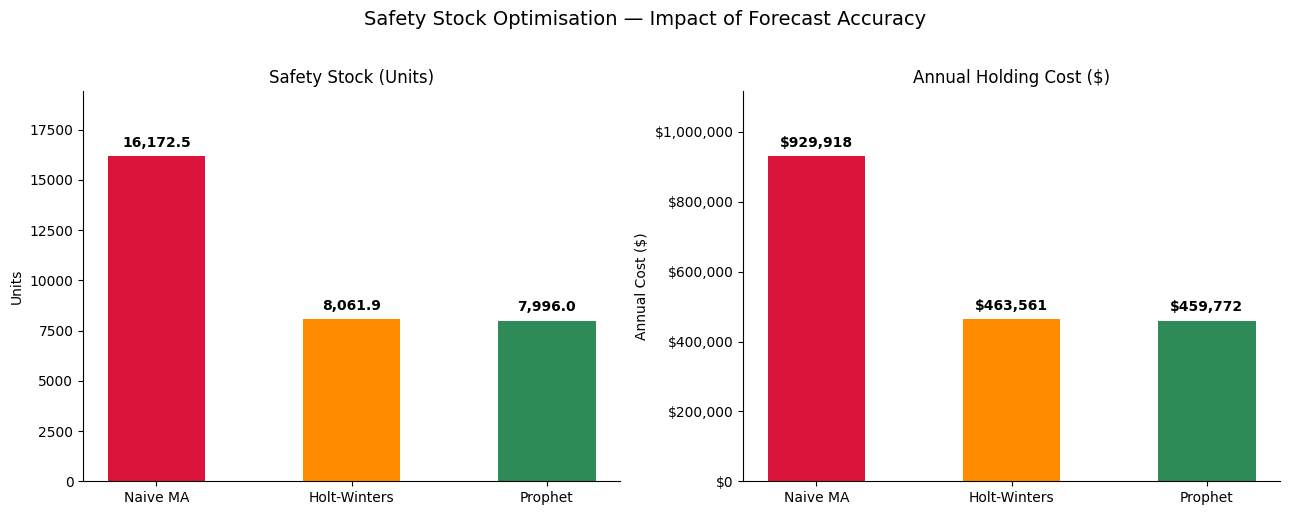


Holding cost saving  Holt-Winters vs Naive : $466,357
Holding cost saving  Prophet      vs Naive : $470,146


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import numpy as np

# --- Rebuild monthly series ---
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
train_m = monthly_sales[monthly_sales.index < '2018-01-01']
test_m  = monthly_sales[monthly_sales.index >= '2018-01-01']

# --- Naive MA: 12-month moving average -> flat forecast ---
naive_fc_val   = train_m.tail(12).mean()
naive_errors   = test_m.values - naive_fc_val
naive_sigma    = naive_errors.std(ddof=1)

# --- Holt-Winters ---
hw_fc = (ExponentialSmoothing(train_m, trend='add', seasonal='add', seasonal_periods=12)
         .fit().forecast(len(test_m)))
hw_fc.index   = test_m.index
hw_errors     = test_m.values - hw_fc.values
hw_sigma      = hw_errors.std(ddof=1)

# --- Prophet ---
train_p = train_m.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mp.add_country_holidays(country_name='US')
mp.fit(train_p)
future     = mp.make_future_dataframe(periods=len(test_m), freq='ME')
fc_full    = mp.predict(future)
prophet_fc = fc_full[fc_full['ds'].isin(test_m.index)]['yhat'].values
prop_errors = test_m.values - prophet_fc
prop_sigma  = prop_errors.std(ddof=1)

# --- Safety stock parameters ---
Z            = 1.65
LT           = 0.132
unit_value   = 230
hold_rate    = 0.25

models   = ['Naive MA', 'Holt-Winters', 'Prophet']
sigmas   = [naive_sigma, hw_sigma, prop_sigma]
colors   = ['crimson', 'darkorange', 'seagreen']

ss_vals  = [Z * s * np.sqrt(LT) for s in sigmas]
hc_vals  = [ss * unit_value * hold_rate for ss in ss_vals]
savings  = [hc_vals[0] - hc for hc in hc_vals]

# --- Summary table ---
summary = pd.DataFrame({
    'Model':                models,
    'Error Std Dev ($)':    ['${:,.0f}'.format(int(s)) for s in sigmas],
    'Safety Stock (units)': ['{:,.1f}'.format(ss)      for ss in ss_vals],
    'Annual Holding Cost':  ['${:,.0f}'.format(int(hc)) for hc in hc_vals],
    'Saving vs Naive':      ['${:,.0f}'.format(int(sv)) for sv in savings],
})
print('--- Safety Stock & Holding Cost Summary ---')
print(summary.to_string(index=False))

# --- Charts ---
x = np.arange(len(models))

fig, (ax_ss, ax_hc) = plt.subplots(1, 2, figsize=(13, 5))

# Left: Safety Stock
bars_ss = ax_ss.bar(x, ss_vals, width=0.5, color=colors)
for bar, val in zip(bars_ss, ss_vals):
    ax_ss.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + max(ss_vals) * 0.02,
               '{:,.1f}'.format(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_ss.set_xticks(x)
ax_ss.set_xticklabels(models, fontsize=10)
ax_ss.set_ylabel('Units')
ax_ss.set_title('Safety Stock (Units)', fontsize=12)
ax_ss.spines['top'].set_visible(False)
ax_ss.spines['right'].set_visible(False)
ax_ss.set_ylim(0, max(ss_vals) * 1.2)

# Right: Annual Holding Cost
bars_hc = ax_hc.bar(x, hc_vals, width=0.5, color=colors)
for bar, val in zip(bars_hc, hc_vals):
    ax_hc.text(bar.get_x() + bar.get_width() / 2,
               bar.get_height() + max(hc_vals) * 0.02,
               '${:,.0f}'.format(int(val)), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_hc.set_xticks(x)
ax_hc.set_xticklabels(models, fontsize=10)
ax_hc.set_ylabel('Annual Cost ($)')
ax_hc.set_title('Annual Holding Cost ($)', fontsize=12)
ax_hc.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: '${:,.0f}'.format(int(v))))
ax_hc.spines['top'].set_visible(False)
ax_hc.spines['right'].set_visible(False)
ax_hc.set_ylim(0, max(hc_vals) * 1.2)

fig.suptitle('Safety Stock Optimisation \u2014 Impact of Forecast Accuracy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Savings callout ---
print()
print('Holding cost saving  Holt-Winters vs Naive : ${:,.0f}'.format(int(savings[1])))
print('Holding cost saving  Prophet      vs Naive : ${:,.0f}'.format(int(savings[2])))

# Section 20 — S&OP Scenario Planning

**Using the forecast as a planning range, not a point estimate.**

No forecast is a fact. The S&OP (Sales & Operations Planning) process requires planners to agree on a *consensus number* from a range of scenarios — not to argue about which single model is correct.

**The three-scenario framework:**

| Scenario | Multiplier | Business Trigger |
|----------|------------|------------------|
| **Pessimistic (−15%)** | ×0.85 | Macro slowdown, customer churn, supply disruption |
| **Base** | ×1.00 | Prophet consensus forecast — most likely outcome |
| **Optimistic (+15%)** | ×1.15 | New contract wins, promotional uplift, market share gain |

**How to use these scenarios in a consensus meeting:**

1. **Sales** anchors to Optimistic — they are incentivised to grow
2. **Finance** anchors to Pessimistic — they manage downside risk
3. **Operations** plans capacity to the Base with buffer to the Optimistic
4. The consensus number sits between Base and Optimistic for most periods

**November demand shock interpretation:**

If actual November sales dramatically exceed the Optimistic scenario, this is a structural signal — not noise. It likely represents an unplanned promotional event, a bulk order from a key account, or a genuine demand acceleration. The planning team should investigate the root cause and update the Prophet model with the new information before the next S&OP cycle.

> The shaded corridor between Pessimistic and Optimistic is the *planner's decision space* — the range within which inventory, capacity, and procurement decisions must be robust.

13:35:34 - cmdstanpy - INFO - Chain [1] start processing
13:35:34 - cmdstanpy - INFO - Chain [1] done processing


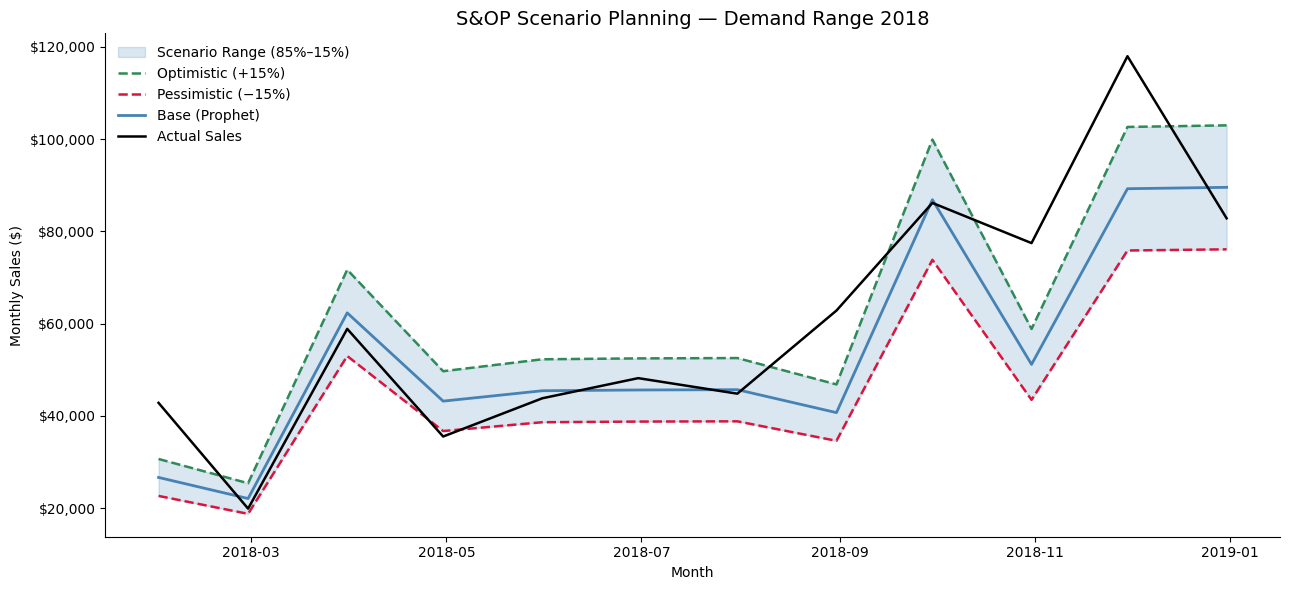

--- S&OP Scenario Table: 2018 ---
  Month Pessimistic    Base Optimistic   Actual
2018-01     $22,675 $26,676    $30,678  $42,839
2018-02     $18,791 $22,107    $25,423  $19,920
2018-03     $52,984 $62,334    $71,684  $58,863
2018-04     $36,728 $43,210    $49,691  $35,541
2018-05     $38,640 $45,459    $52,278  $43,825
2018-06     $38,782 $45,626    $52,470  $48,190
2018-07     $38,838 $45,692    $52,545  $44,825
2018-08     $34,611 $40,719    $46,827  $62,837
2018-09     $73,822 $86,850    $99,877  $86,152
2018-10     $43,490 $51,165    $58,840  $77,448
2018-11     $75,846 $89,231   $102,615 $117,938
2018-12     $76,100 $89,530   $102,959  $82,825


In [24]:
from prophet import Prophet

# --- Rebuild monthly series and fit Prophet ---
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
train_m = monthly_sales[monthly_sales.index < '2018-01-01']
test_m  = monthly_sales[monthly_sales.index >= '2018-01-01']

train_p = train_m.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
mp.add_country_holidays(country_name='US')
mp.fit(train_p)

future  = mp.make_future_dataframe(periods=len(test_m), freq='ME')
fc_full = mp.predict(future)
base_fc = fc_full[fc_full['ds'].isin(test_m.index)][['ds', 'yhat']].reset_index(drop=True)

dates        = base_fc['ds']
base         = base_fc['yhat'].values
optimistic   = base * 1.15
pessimistic  = base * 0.85

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(dates, pessimistic, optimistic,
                color='steelblue', alpha=0.2, label='Scenario Range (85%\u201315%)')

ax.plot(dates, optimistic,  color='seagreen',   linestyle='--', linewidth=1.8, label='Optimistic (+15%)')
ax.plot(dates, pessimistic, color='crimson',     linestyle='--', linewidth=1.8, label='Pessimistic (\u221215%)')
ax.plot(dates, base,        color='steelblue',   linestyle='-',  linewidth=2.0, label='Base (Prophet)')
ax.plot(test_m.index, test_m.values,
                            color='black',       linestyle='-',  linewidth=1.8, label='Actual Sales')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '${:,.0f}'.format(int(x))))
ax.set_title('S&OP Scenario Planning \u2014 Demand Range 2018', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Sales ($)')
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# --- Print scenario table ---
tbl = pd.DataFrame({
    'Month':       dates.dt.strftime('%Y-%m'),
    'Pessimistic': ['${:,.0f}'.format(int(v)) for v in pessimistic],
    'Base':        ['${:,.0f}'.format(int(v)) for v in base],
    'Optimistic':  ['${:,.0f}'.format(int(v)) for v in optimistic],
    'Actual':      ['${:,.0f}'.format(int(v)) for v in test_m.values],
})
print('--- S&OP Scenario Table: 2018 ---')
print(tbl.to_string(index=False))

# Conclusions & Recommendations

---

## Key Findings

| Finding | Detail |
|---------|--------|
| **Best model** | Prophet — MAPE 15.79%, lowest across all 10 methods evaluated |
| **Annual holding cost saving** | Switching from Naive MA to Prophet saves **$470,146/year** in safety stock holding costs |
| **A-items requiring weekly review** | Phones and Chairs — high value, sufficient history, dedicated Prophet models |
| **Intermittent demand** | Copiers require Croston's method — MAPE is undefined on zero-demand months |
| **ML readiness** | XGBoost underperforms with <5,000 training rows — requires more history for production deployment |

## Model Ranking (by MAPE)

| Rank | Model | MAPE | Verdict |
|------|-------|------|---------|
| 1 | **Prophet** | 15.79% | Deploy now |
| 2 | **Holt-Winters** | 17.40% | Deploy as backup |
| 3 | Linear Trend+Seasonal | 19.00% | Excel baseline |
| 4 | XGBoost | 25.95% | Revisit with more data |
| 5 | Seasonal Index | 26.74% | Excel baseline |
| 6 | SARIMA | 27.05% | Needs longer history |
| 7 | YoY Growth | 27.73% | Simple Excel |
| 8 | Weighted MA | 48.66% | Retire |
| 9 | Exp Smoothing | 46.71% | Retire |
| 10 | Naive MA | 50.80% | Benchmark only |

## Next Steps

### Immediate Actions (0–30 days)

1. **Deploy Prophet in production** for aggregate and A-item sub-category forecasts
2. **Retire Naive MA, Exp Smoothing, and Weighted MA** — all three score below the naive benchmark and destroy forecast value
3. **Implement Croston's method** for Copiers and any SKU where >30% of months have zero demand

### Short Term (30–90 days)

4. **Set up monthly MAPE monitoring dashboard** — track forecast accuracy per model, per SKU, per region
5. **Establish FVA review cadence** — monthly comparison of model MAPE vs naive benchmark to confirm models continue adding value
6. **Expand ABC/XYZ segmentation** to assign the right model to every sub-category automatically

### Medium Term (90–180 days)

7. **Expand to SKU × Region level forecasting** — build individual Prophet models per sub-category per region using hierarchical reconciliation
8. **Re-evaluate XGBoost** once 3+ additional years of daily data accumulate — gradient boosting should outperform at scale
9. **Integrate external signals** — macroeconomic indicators, promotions calendar, and customer order pipeline into the Prophet regressors

---

*Built using the IBF (Institute of Business Forecasting) framework.*  
*Models evaluated: Naive MA, Exponential Smoothing, Weighted MA, YoY Growth, Seasonal Index, Linear Trend+Seasonal, SARIMA, XGBoost, Holt-Winters, Prophet, Croston's.*